# BRISC DINOv3 Classification Experiments — Revised Paper

This notebook implements the **complete classification experiment pipeline** for the revised paper.  
It covers dataset preparation, exact-duplicate cleaning, five model architectures, model comparison,
three-seed and five-fold validation, augmentation ablation, calibration, statistical comparison,
and an independent binary classification experiment.

**Scope exclusions:** No XAI, Lucent, Deep Dream, GradCAM, Integrated Gradients, attention maps, or LLM reporter.  
This notebook is **classification only**.

The original baseline notebook (`dinov3_optimization_experiments.ipynb`) and the original BRISC dataset are **never modified**.

In [6]:
%pip install -q transformers timm huggingface_hub imagehash Pillow scipy statsmodels

## Section 1 — Setup and Authentication

The Hugging Face token is retrieved securely via Colab Secrets (`userdata`) or an environment variable.  
No token is ever printed or hardcoded.

In [7]:
import os

# ── Option 1: Paste your HF token manually here ──────────────────────────
MANUAL_HF_TOKEN = ""  # e.g. "hf_abc123..."  (leave empty to use Colab Secrets or env var)

# ── Resolve token (manual > Colab Secrets > env var) ─────────────────────
if MANUAL_HF_TOKEN:
    HF_TOKEN = MANUAL_HF_TOKEN
else:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get("HF_TOKEN")
    except Exception:
        HF_TOKEN = os.environ.get("HF_TOKEN", None)

if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)
    print("HuggingFace authentication successful.")
else:
    print("No HF_TOKEN found. Public models will still work.")

HuggingFace authentication successful.


## Section 2 — Mount Drive & Extract Dataset

The BRISC dataset is extracted into two copies:
- **`BRISC_original`** — the untouched, read-only dataset exactly as downloaded.
- **`BRISC_exact_cleaned`** — a working copy where only exact SHA-256 duplicates will be removed.

`BRISC_original` is never modified or deleted.

In [8]:
import shutil
import zipfile

from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH = "/content/drive/MyDrive/Data/BT_Images.zip"
ORIGINAL_ROOT = "/content/BRISC_original"
CLEAN_ROOT = "/content/BRISC_exact_cleaned"
TEMP_EXTRACT = "/content/_bt_extract_temp"

# --- Step 1: Extract to temporary location ---------------------------------
if not os.path.exists(ORIGINAL_ROOT):
    print("Extracting dataset from zip...")
    if os.path.exists(TEMP_EXTRACT):
        shutil.rmtree(TEMP_EXTRACT)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(TEMP_EXTRACT)

    # Detect folder structure: could be Training/Testing or train/test
    extracted = os.listdir(TEMP_EXTRACT)
    # If there is a single top-level folder, descend into it
    if len(extracted) == 1 and os.path.isdir(os.path.join(TEMP_EXTRACT, extracted[0])):
        inner = os.path.join(TEMP_EXTRACT, extracted[0])
        extracted = os.listdir(inner)
        src_base = inner
    else:
        src_base = TEMP_EXTRACT

    # Detect train/test folder names (case-insensitive)
    folder_map = {}
    for d in sorted(os.listdir(src_base)):
        dl = d.lower()
        full = os.path.join(src_base, d)
        if not os.path.isdir(full):
            continue
        if "train" in dl:
            folder_map["train"] = full
        elif "test" in dl:
            folder_map["test"] = full

    assert "train" in folder_map and "test" in folder_map, (
        f"Could not detect train/test folders. Found: {os.listdir(src_base)}"
    )

    os.makedirs(ORIGINAL_ROOT, exist_ok=True)
    shutil.copytree(folder_map["train"], os.path.join(ORIGINAL_ROOT, "train"))
    shutil.copytree(folder_map["test"], os.path.join(ORIGINAL_ROOT, "test"))

    shutil.rmtree(TEMP_EXTRACT)
    print(f"BRISC_original created at {ORIGINAL_ROOT}")
else:
    print(f"BRISC_original already exists at {ORIGINAL_ROOT}")

# --- Step 2: Create BRISC_exact_cleaned as a full copy ----------------------
if os.path.exists(CLEAN_ROOT):
    shutil.rmtree(CLEAN_ROOT)

shutil.copytree(ORIGINAL_ROOT, CLEAN_ROOT)
print(f"BRISC_exact_cleaned created at {CLEAN_ROOT}")
print("Both dataset versions ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BRISC_original already exists at /content/BRISC_original
BRISC_exact_cleaned created at /content/BRISC_exact_cleaned
Both dataset versions ready.


## Section 3 — Central Configuration

In [9]:
from pathlib import Path

CONFIG = {
    # Model
    "model_id": "facebook/dinov3-vitb16-pretrain-lvd1689m",
    "img_size": 224,
    "batch_size": 32,
    "hidden_dim": 768,

    # Logistic Regression
    "C": 1.0,
    "max_iter": 2000,

    # Split
    "val_split": 0.15,
    "seeds": [42, 123, 2026],
    "n_folds": 5,

    # Training (PyTorch models)
    "epochs_resnet": 25,
    "epochs_mlp": 30,
    "epochs_finetune": 25,
    "patience": 7,
    "lr_head": 1e-3,
    "lr_backbone": 1e-5,
    "lr_resnet": 1e-4,
    "weight_decay": 1e-4,
    "dropout": 0.3,

    # Bootstrap
    "n_bootstrap": 2000,

    # Paths
    "original_train": "/content/BRISC_original/train",
    "original_test": "/content/BRISC_original/test",
    "clean_train": "/content/BRISC_exact_cleaned/train",
    "clean_test": "/content/BRISC_exact_cleaned/test",

    # Output dirs
    "out_original": "results_original_baseline",
    "out_clean": "results_clean_baseline",
    "out_comparison": "results_model_comparison",
    "out_seed": "results_seed_analysis",
    "out_cv": "results_cross_validation",
    "out_aug": "results_augmentation",
    "out_cal": "results_calibration",
    "out_binary": "results_binary",
}

# Print config
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

  model_id: facebook/dinov3-vitb16-pretrain-lvd1689m
  img_size: 224
  batch_size: 32
  hidden_dim: 768
  C: 1.0
  max_iter: 2000
  val_split: 0.15
  seeds: [42, 123, 2026]
  n_folds: 5
  epochs_resnet: 25
  epochs_mlp: 30
  epochs_finetune: 25
  patience: 7
  lr_head: 0.001
  lr_backbone: 1e-05
  lr_resnet: 0.0001
  weight_decay: 0.0001
  dropout: 0.3
  n_bootstrap: 2000
  original_train: /content/BRISC_original/train
  original_test: /content/BRISC_original/test
  clean_train: /content/BRISC_exact_cleaned/train
  clean_test: /content/BRISC_exact_cleaned/test
  out_original: results_original_baseline
  out_clean: results_clean_baseline
  out_comparison: results_model_comparison
  out_seed: results_seed_analysis
  out_cv: results_cross_validation
  out_aug: results_augmentation
  out_cal: results_calibration
  out_binary: results_binary


## Section 4 — Reproducibility & Environment Recording

In [10]:
import sys
import random
import json
import hashlib
import time
import copy
import warnings
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
from tqdm.auto import tqdm

from transformers import AutoModel
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, cohen_kappa_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    roc_auc_score, brier_score_loss, log_loss,
)
from scipy import stats


def set_seed(seed: int = 42):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

env_info = {
    "python": sys.version,
    "pytorch": torch.__version__,
    "torchvision": torchvision.__version__,
    "transformers": __import__("transformers").__version__,
    "sklearn": sklearn.__version__,
    "numpy": np.__version__,
    # "scipy": stats.scipy_version,93

    "matplotlib": matplotlib.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda if torch.cuda.is_available() else "N/A",
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A",
    "device": str(device),
    "dinov3_checkpoint": CONFIG["model_id"],
    "timestamp": datetime.now().isoformat(),
}

for k, v in env_info.items():
    print(f"  {k}: {v}")

  python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
  pytorch: 2.11.0+cu128
  torchvision: 0.26.0+cu128
  transformers: 5.15.0
  sklearn: 1.6.1
  numpy: 2.1.3
  matplotlib: 3.10.0
  cuda_available: True
  cuda_version: 12.8
  gpu_name: NVIDIA L4
  device: cuda
  dinov3_checkpoint: facebook/dinov3-vitb16-pretrain-lvd1689m
  timestamp: 2026-08-23T18:43:46.773248


## Section 5 — Dataset Audit

Scan both the original and clean datasets to record image counts, class distributions,
and image dimensions.

In [11]:
VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def scan_directory(root: str, split_name: str) -> pd.DataFrame:
    """Walk a class-subfolder image directory and return an audit DataFrame."""
    rows = []
    root_path = Path(root)
    for class_dir in sorted(root_path.iterdir()):
        if not class_dir.is_dir():
            continue
        # Normalize class name: strip _tumor suffix if present
        class_name = class_dir.name.replace("_tumor", "").lower()
        for img_path in sorted(class_dir.iterdir()):
            if img_path.suffix.lower() not in VALID_EXT:
                continue
            try:
                img = Image.open(img_path)
                w, h = img.size
            except Exception:
                w, h = -1, -1
            rows.append({
                "filepath": str(img_path),
                "filename": img_path.name,
                "class": class_name,
                "split": split_name,
                "width": w,
                "height": h,
            })
    return pd.DataFrame(rows)


df_orig_train = scan_directory(CONFIG["original_train"], "train")
df_orig_test = scan_directory(CONFIG["original_test"], "test")
df_orig = pd.concat([df_orig_train, df_orig_test], ignore_index=True)

print(f"BRISC_original — Train images: {len(df_orig_train)}")
print(f"BRISC_original — Test images:  {len(df_orig_test)}")
print(f"BRISC_original — Total:        {len(df_orig)}")

print("\nTrain class distribution:")
print(df_orig_train["class"].value_counts().sort_index().to_string())

print("\nTest class distribution:")
print(df_orig_test["class"].value_counts().sort_index().to_string())

print("\nImage dimensions (width x height):")
print(f"  Min:  {df_orig['width'].min()} x {df_orig['height'].min()}")
print(f"  Max:  {df_orig['width'].max()} x {df_orig['height'].max()}")
print(f"  Mode: {df_orig['width'].mode().iloc[0]} x {df_orig['height'].mode().iloc[0]}")

train_classes = sorted(df_orig_train["class"].unique())
test_classes = sorted(df_orig_test["class"].unique())
assert train_classes == test_classes, (
    f"Class mismatch: train={train_classes}, test={test_classes}"
)
CLASS_NAMES = train_classes
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)
print(f"\nClass names verified identical: {CLASS_NAMES}")
print(f"Number of classes: {NUM_CLASSES}")

BRISC_original — Train images: 5000
BRISC_original — Test images:  1000
BRISC_original — Total:        6000

Train class distribution:
class
glioma        1147
meningioma    1329
no            1067
pituitary     1457

Test class distribution:
class
glioma        254
meningioma    306
no            140
pituitary     300

Image dimensions (width x height):
  Min:  174 x 195
  Max:  1365 x 1427
  Mode: 512 x 512

Class names verified identical: ['glioma', 'meningioma', 'no', 'pituitary']
Number of classes: 4


## Section 6 — SHA-256 Exact Duplicate Audit

Compute SHA-256 hashes for every image. Identify exact byte-identical duplicates.  
**No perceptual hash, SSIM, or visual similarity is used for removal decisions.**  
Near-duplicate images are intentionally preserved.

In [12]:
def sha256_file(filepath: str) -> str:
    """Compute SHA-256 hash of an entire file."""
    h = hashlib.sha256()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()


print("Computing SHA-256 hashes for BRISC_original...")
df_orig["sha256"] = [sha256_file(fp) for fp in tqdm(df_orig["filepath"], desc="Hashing")]

# Identify duplicate groups
hash_counts = df_orig["sha256"].value_counts()
dup_hashes = hash_counts[hash_counts > 1].index.tolist()

# Assign duplicate group IDs
hash_to_group = {}
group_counter = 0
for h in sorted(dup_hashes):
    hash_to_group[h] = group_counter
    group_counter += 1

df_orig["dup_group_id"] = df_orig["sha256"].map(hash_to_group).fillna(-1).astype(int)

# Classify duplicate type
def classify_dup_type(group_df):
    splits = set(group_df["split"])
    if splits == {"train", "test"}:
        return "cross_train_test"
    elif splits == {"train"}:
        return "within_train"
    elif splits == {"test"}:
        return "within_test"
    return "unknown"


dup_type_map = {}
for gid in range(group_counter):
    group = df_orig[df_orig["dup_group_id"] == gid]
    dup_type_map[gid] = classify_dup_type(group)

df_orig["dup_type"] = df_orig["dup_group_id"].map(dup_type_map).fillna("none")

# Save full audit
OUT_ORIG = Path(CONFIG["out_original"])
OUT_ORIG.mkdir(parents=True, exist_ok=True)
audit_cols = ["filepath", "filename", "class", "split", "sha256", "dup_group_id", "dup_type"]
df_orig[audit_cols].to_csv(OUT_ORIG / "duplicate_audit.csv", index=False)

# Summary
df_dups = df_orig[df_orig["dup_group_id"] >= 0]
n_within_train = sum(1 for v in dup_type_map.values() if v == "within_train")
n_within_test = sum(1 for v in dup_type_map.values() if v == "within_test")
n_cross = sum(1 for v in dup_type_map.values() if v == "cross_train_test")

print(f"\nTotal duplicate groups: {group_counter}")
print(f"  within_train groups:    {n_within_train}")
print(f"  within_test groups:     {n_within_test}")
print(f"  cross_train_test groups: {n_cross}")
print(f"  Total images in duplicate groups: {len(df_dups)}")
print(f"\nSaved full audit to {OUT_ORIG / 'duplicate_audit.csv'}")

Computing SHA-256 hashes for BRISC_original...


Hashing:   0%|          | 0/6000 [00:00<?, ?it/s]


Total duplicate groups: 46
  within_train groups:    34
  within_test groups:     5
  cross_train_test groups: 7
  Total images in duplicate groups: 96

Saved full audit to results_original_baseline/duplicate_audit.csv


## Section 7 — Exact Duplicate Cleaning (BRISC_exact_cleaned)

Removal rules (applied only to `BRISC_exact_cleaned`, never to `BRISC_original`):

1. **Cross-split duplicates**: Remove every training copy (preserve the test copy) to prevent data leakage.
2. **Within-train duplicates**: Keep the lexicographically-first filepath; remove the rest.
3. **Within-test duplicates**: Keep the lexicographically-first filepath; remove the rest.

**Near-duplicate images are intentionally NOT removed.**  
Only exact SHA-256 byte-identical files are cleaned.

In [13]:
# Build removal list
removed_records = []

for gid in range(group_counter):
    group = df_orig[df_orig["dup_group_id"] == gid].sort_values("filepath")
    dtype = dup_type_map[gid]

    if dtype == "cross_train_test":
        # Keep all test copies, remove all train copies
        test_copies = group[group["split"] == "test"].sort_values("filepath")
        train_copies = group[group["split"] == "train"]
        kept_fp = test_copies.iloc[0]["filepath"]  # canonical kept file
        for _, row in train_copies.iterrows():
            removed_records.append({
                "removed_filepath": row["filepath"],
                "kept_filepath": kept_fp,
                "class": row["class"],
                "split": row["split"],
                "sha256": row["sha256"],
                "reason": "cross_split_duplicate_remove_train_copy",
            })
        # Also remove extra test copies beyond the first
        if len(test_copies) > 1:
            for _, row in test_copies.iloc[1:].iterrows():
                removed_records.append({
                    "removed_filepath": row["filepath"],
                    "kept_filepath": kept_fp,
                    "class": row["class"],
                    "split": row["split"],
                    "sha256": row["sha256"],
                    "reason": "cross_split_duplicate_extra_test_copy",
                })

    elif dtype == "within_train":
        # Keep first sorted, remove rest
        kept_fp = group.iloc[0]["filepath"]
        for _, row in group.iloc[1:].iterrows():
            removed_records.append({
                "removed_filepath": row["filepath"],
                "kept_filepath": kept_fp,
                "class": row["class"],
                "split": row["split"],
                "sha256": row["sha256"],
                "reason": "within_train_duplicate",
            })

    elif dtype == "within_test":
        # Keep first sorted, remove rest
        kept_fp = group.iloc[0]["filepath"]
        for _, row in group.iloc[1:].iterrows():
            removed_records.append({
                "removed_filepath": row["filepath"],
                "kept_filepath": kept_fp,
                "class": row["class"],
                "split": row["split"],
                "sha256": row["sha256"],
                "reason": "within_test_duplicate",
            })

df_removed = pd.DataFrame(removed_records)

# --- Physically remove files from BRISC_exact_cleaned -----------------------
# Map original paths to clean paths
n_removed_train = 0
n_removed_test = 0
for _, row in df_removed.iterrows():
    orig_path = row["removed_filepath"]
    clean_path = orig_path.replace(str(ORIGINAL_ROOT), str(CLEAN_ROOT))
    if os.path.exists(clean_path):
        os.remove(clean_path)
        if row["split"] == "train":
            n_removed_train += 1
        else:
            n_removed_test += 1

# Save removal log
OUT_CLEAN = Path(CONFIG["out_clean"])
OUT_CLEAN.mkdir(parents=True, exist_ok=True)
df_removed.to_csv(OUT_CLEAN / "removed_exact_duplicates.csv", index=False)

# --- Build clean dataset manifest -------------------------------------------
df_clean_train = scan_directory(CONFIG["clean_train"], "train")
df_clean_test = scan_directory(CONFIG["clean_test"], "test")
df_clean = pd.concat([df_clean_train, df_clean_test], ignore_index=True)
df_clean.to_csv(OUT_CLEAN / "clean_dataset_manifest.csv", index=False)

# --- Print summary -----------------------------------------------------------
print("=" * 80)
print("EXACT DUPLICATE CLEANING SUMMARY")
print("=" * 80)
print(f"Original training images:    {len(df_orig_train)}")
print(f"Original testing images:     {len(df_orig_test)}")
print(f"Clean training images:       {len(df_clean_train)}")
print(f"Clean testing images:        {len(df_clean_test)}")
print(f"Exact duplicate groups:      {group_counter}")
print(f"Removed from training:       {n_removed_train}")
print(f"Removed from testing:        {n_removed_test}")
print(f"Cross-split duplicate groups: {n_cross}")
print()
print("Near-duplicate images were intentionally NOT removed.")
print("Only exact SHA-256 byte-identical files were cleaned.")
print(f"\nSaved removal log: {OUT_CLEAN / 'removed_exact_duplicates.csv'}")
print(f"Saved clean manifest: {OUT_CLEAN / 'clean_dataset_manifest.csv'}")

EXACT DUPLICATE CLEANING SUMMARY
Original training images:    5000
Original testing images:     1000
Clean training images:       4955
Clean testing images:        995
Exact duplicate groups:      46
Removed from training:       45
Removed from testing:        5
Cross-split duplicate groups: 7

Near-duplicate images were intentionally NOT removed.
Only exact SHA-256 byte-identical files were cleaned.

Saved removal log: results_clean_baseline/removed_exact_duplicates.csv
Saved clean manifest: results_clean_baseline/clean_dataset_manifest.csv


### Post-Clean Verification

Re-hash `BRISC_exact_cleaned` and assert zero exact duplicate hashes across train and test.

In [14]:
print("Post-clean SHA-256 verification...")
df_clean["sha256"] = [sha256_file(fp) for fp in tqdm(df_clean["filepath"], desc="Verifying")]

clean_train_hashes = set(df_clean.loc[df_clean["split"] == "train", "sha256"])
clean_test_hashes = set(df_clean.loc[df_clean["split"] == "test", "sha256"])
cross_clean = clean_train_hashes & clean_test_hashes

assert len(cross_clean) == 0, (
    f"VERIFICATION FAILED: {len(cross_clean)} cross-split duplicate hashes remain!"
)
print(f"VERIFIED: Zero exact duplicate hashes across train and test in BRISC_exact_cleaned.")
print(f"Clean train unique hashes: {len(clean_train_hashes)}")
print(f"Clean test unique hashes:  {len(clean_test_hashes)}")

Post-clean SHA-256 verification...


Verifying:   0%|          | 0/5950 [00:00<?, ?it/s]

VERIFIED: Zero exact duplicate hashes across train and test in BRISC_exact_cleaned.
Clean train unique hashes: 4955
Clean test unique hashes:  995


## Section 8 — Experiment Output Directories

In [15]:
OUT_DIRS = {}
for key in ["out_original", "out_clean", "out_comparison", "out_seed",
             "out_cv", "out_aug", "out_cal", "out_binary"]:
    p = Path(CONFIG[key])
    p.mkdir(parents=True, exist_ok=True)
    OUT_DIRS[key] = p
    print(f"  {key}: {p}")

# Save environment info
with open(OUT_DIRS["out_comparison"] / "environment.json", "w") as f:
    json.dump(env_info, f, indent=2, default=str)
print(f"\nEnvironment info saved to {OUT_DIRS['out_comparison'] / 'environment.json'}")

  out_original: results_original_baseline
  out_clean: results_clean_baseline
  out_comparison: results_model_comparison
  out_seed: results_seed_analysis
  out_cv: results_cross_validation
  out_aug: results_augmentation
  out_cal: results_calibration
  out_binary: results_binary

Environment info saved to results_model_comparison/environment.json


## Section 9 — Fixed Clean Validation Split

Create one stratified train/validation split from the clean training set (15% validation).  
The clean test set is never used for model selection, hyperparameter tuning, or early stopping.

All splitting is performed at the **image level**. Patient-level independence **cannot be verified**
because reliable patient identifiers are not available in the current dataset metadata.

In [16]:
clean_train_fps = df_clean_train["filepath"].tolist()
clean_train_labels = df_clean_train["class"].tolist()
clean_train_labels_int = [CLASS_TO_IDX[c] for c in clean_train_labels]

clean_test_fps = df_clean_test["filepath"].tolist()
clean_test_labels = df_clean_test["class"].tolist()
clean_test_labels_int = [CLASS_TO_IDX[c] for c in clean_test_labels]

idx_train, idx_val = train_test_split(
    list(range(len(clean_train_fps))),
    test_size=CONFIG["val_split"],
    stratify=clean_train_labels_int,
    random_state=42,
)

# Build manifest
manifest_rows = []
for i in idx_train:
    manifest_rows.append({
        "filepath": clean_train_fps[i],
        "class": clean_train_labels[i],
        "label_int": clean_train_labels_int[i],
        "partition": "train",
    })
for i in idx_val:
    manifest_rows.append({
        "filepath": clean_train_fps[i],
        "class": clean_train_labels[i],
        "label_int": clean_train_labels_int[i],
        "partition": "validation",
    })
for fp, cls, lab in zip(clean_test_fps, clean_test_labels, clean_test_labels_int):
    manifest_rows.append({
        "filepath": fp, "class": cls, "label_int": lab, "partition": "test",
    })

df_split = pd.DataFrame(manifest_rows)
df_split.to_csv(OUT_DIRS["out_clean"] / "fixed_split_manifest.csv", index=False)

# Convenience lists
train_fps = [clean_train_fps[i] for i in idx_train]
train_labs = [clean_train_labels_int[i] for i in idx_train]
val_fps = [clean_train_fps[i] for i in idx_val]
val_labs = [clean_train_labels_int[i] for i in idx_val]
test_fps = clean_test_fps
test_labs = clean_test_labels_int

print("Partition sizes:")
print(df_split["partition"].value_counts().to_string())
print("\nClass counts per partition:")
print(df_split.groupby(["partition", "class"]).size().unstack(fill_value=0).to_string())
print("\nAll splitting is performed at the image level.")
print("Patient-level independence cannot be verified — reliable patient IDs are unavailable.")
print(f"\nSaved to {OUT_DIRS['out_clean'] / 'fixed_split_manifest.csv'}")

Partition sizes:
partition
train         4211
test           995
validation     744

Class counts per partition:
class       glioma  meningioma   no  pituitary
partition                                     
test           253         303  139        300
train          975        1113  899       1224
validation     172         197  159        216

All splitting is performed at the image level.
Patient-level independence cannot be verified — reliable patient IDs are unavailable.

Saved to results_clean_baseline/fixed_split_manifest.csv


## Section 10 — Preprocessing & Dataset Classes

**Minimal preprocessing** for the main model comparison:
- Resize to 224×224
- Convert to tensor
- Normalize with ImageNet statistics

No augmentation is applied during the main model comparison.
The same preprocessing is used across all comparable models.

In [17]:
# --- Minimal transform (main comparison) ------------------------------------
transform_minimal = T.Compose([
    T.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- Conservative MRI augmentation ------------------------------------------
transform_conservative = T.Compose([
    T.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- Aggressive augmentation (reproduce original paper pipeline) ------------
transform_aggressive = T.Compose([
    T.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    T.RandAugment(num_ops=2, magnitude=9),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    T.RandomErasing(p=0.25),
])


class ImageListDataset(Dataset):
    """Dataset from a list of (filepath, label) pairs."""

    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]


print(f"Minimal:      Resize({CONFIG['img_size']}x{CONFIG['img_size']}) -> ToTensor -> ImageNet Normalize")
print(f"Conservative: + RandomRotation(10) + RandomAffine(translate=0.05, scale=0.95-1.05)")
print(f"Aggressive:   + RandAugment + HFlip + VFlip + ColorJitter + RandomErasing")

Minimal:      Resize(224x224) -> ToTensor -> ImageNet Normalize
Conservative: + RandomRotation(10) + RandomAffine(translate=0.05, scale=0.95-1.05)
Aggressive:   + RandAugment + HFlip + VFlip + ColorJitter + RandomErasing


## Section 11 — DINOv3 Backbone Loading

In [18]:
print(f"Loading backbone: {CONFIG['model_id']}")

backbone = AutoModel.from_pretrained(CONFIG["model_id"], token=HF_TOKEN)
backbone = backbone.to(device)
backbone.eval()

for param in backbone.parameters():
    param.requires_grad = False

total_params = sum(p.numel() for p in backbone.parameters())
trainable_params = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
pct_trainable = 100.0 * trainable_params / total_params if total_params > 0 else 0.0

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Percentage trainable: {pct_trainable:.4f}%")
assert trainable_params == 0, f"Expected 0 trainable params, got {trainable_params}"

hidden_dim = getattr(backbone.config, "hidden_size", 768)
print(f"Feature dimension:    {hidden_dim}")
assert hidden_dim == CONFIG["hidden_dim"], f"Expected {CONFIG['hidden_dim']}, got {hidden_dim}"

Loading backbone: facebook/dinov3-vitb16-pretrain-lvd1689m


config.json:   0%|          | 0.00/744 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  343MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Total parameters:     85,660,416
Trainable parameters: 0
Percentage trainable: 0.0000%
Feature dimension:    768


## Section 12 — Feature Extraction & Metrics Utilities

In [19]:
@torch.no_grad()
def extract_features(filepaths, labels, backbone, transform, batch_size, device, desc=""):
    """Extract CLS token features from a frozen DINOv3 backbone."""
    ds = ImageListDataset(filepaths, labels, transform)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)
    all_feats, all_labs = [], []
    for images, labs in tqdm(loader, desc=desc):
        images = images.to(device)
        out = backbone(images)
        feats = out.last_hidden_state[:, 0]
        all_feats.append(feats.cpu().numpy())
        all_labs.append(labs.numpy() if isinstance(labs, torch.Tensor) else np.array(labs))
    return np.concatenate(all_feats), np.concatenate(all_labs)


def compute_multiclass_metrics(y_true, y_pred, class_names):
    """Compute all multiclass metrics."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "kappa": cohen_kappa_score(y_true, y_pred),
    }


def compute_per_class_metrics(y_true, y_pred, class_names):
    """Compute per-class precision, recall, F1, and support."""
    report = classification_report(y_true, y_pred, target_names=class_names,
                                   output_dict=True, zero_division=0)
    rows = []
    for cls in class_names:
        rows.append({
            "class": cls,
            "precision": report[cls]["precision"],
            "recall": report[cls]["recall"],
            "f1": report[cls]["f1-score"],
            "support": int(report[cls]["support"]),
        })
    return pd.DataFrame(rows)


def plot_confusion_matrix(cm, class_names, title, save_prefix, normalize=False):
    """Plot and save confusion matrix."""
    if normalize:
        cm_plot = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt_func = lambda v: f"{v:.1%}"
    else:
        cm_plot = cm.astype(float)
        fmt_func = lambda v: f"{int(v)}"

    fig, ax = plt.subplots(figsize=(7, 6))
    cmap = LinearSegmentedColormap.from_list("blues", ["#ffffff", "#3274a1"])
    im = ax.imshow(cm_plot, interpolation="nearest", cmap=cmap)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    n = len(class_names)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels(class_names, fontsize=10)

    thresh = cm_plot.max() / 2.0
    for i in range(n):
        for j in range(n):
            color = "white" if cm_plot[i, j] > thresh else "black"
            ax.text(j, i, fmt_func(cm_plot[i, j]), ha="center", va="center",
                    color=color, fontsize=12, fontweight="bold")

    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Actual", fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    plt.tight_layout()

    for ext in ["png", "pdf"]:
        fig.savefig(f"{save_prefix}.{ext}", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def count_parameters(model):
    """Count total and trainable parameters."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


print("Utility functions defined.")

Utility functions defined.


## Section 13 — Model A: Frozen DINOv3 + Logistic Regression (Original Baseline)

This reproduces the official BRISC dataset baseline on `BRISC_original` — identical to the existing
baseline notebook experiment.

**Label**: Original official split baseline (no duplicate cleaning applied).

Extracting features from BRISC_original training set...


Original Train:   0%|          | 0/157 [00:00<?, ?it/s]

Extracting features from BRISC_original test set...


Original Test:   0%|          | 0/32 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Original Baseline — Validation metrics:
  accuracy: 0.9680
  balanced_accuracy: 0.9682
  macro_precision: 0.9700
  macro_recall: 0.9682
  macro_f1: 0.9690
  weighted_precision: 0.9681
  weighted_recall: 0.9680
  weighted_f1: 0.9680
  kappa: 0.9571

Original Baseline — Test metrics:
  accuracy: 0.9670
  balanced_accuracy: 0.9698
  macro_precision: 0.9726
  macro_recall: 0.9698
  macro_f1: 0.9709
  weighted_precision: 0.9677
  weighted_recall: 0.9670
  weighted_f1: 0.9670
  kappa: 0.9549
  model: A_DINOv3_LR_original
  training_time_s: 12.9915

Per-class test metrics:
     class  precision   recall       f1  support
    glioma   0.979167 0.925197 0.951417      254
meningioma   0.927900 0.967320 0.947200      306
        no   1.000000 1.000000 1.000000      140
 pituitary   0.983389 0.986667 0.985025      300


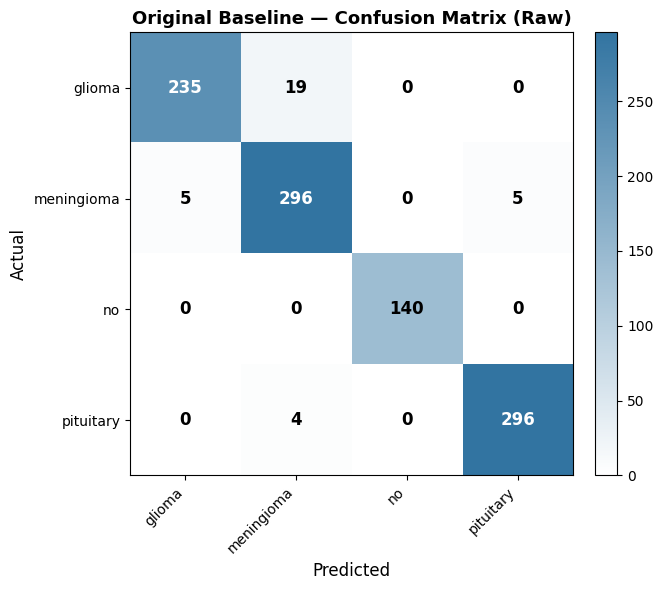

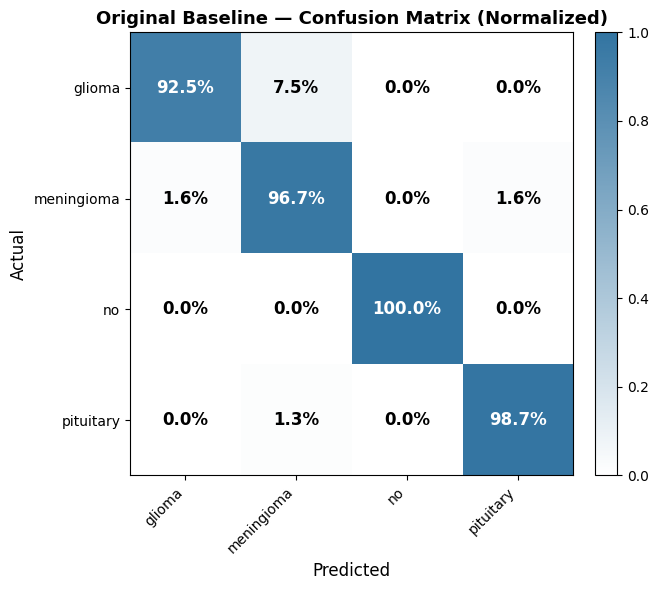

In [20]:
# --- Extract features from BRISC_original -----------------------------------
orig_train_fps = df_orig_train["filepath"].tolist()
orig_train_labels_str = df_orig_train["class"].tolist()
orig_train_labels_int = [CLASS_TO_IDX[c] for c in orig_train_labels_str]

orig_test_fps = df_orig_test["filepath"].tolist()
orig_test_labels_str = df_orig_test["class"].tolist()
orig_test_labels_int = [CLASS_TO_IDX[c] for c in orig_test_labels_str]

print("Extracting features from BRISC_original training set...")
X_orig_train, y_orig_train = extract_features(
    orig_train_fps, orig_train_labels_int, backbone, transform_minimal,
    CONFIG["batch_size"], device, "Original Train"
)

print("Extracting features from BRISC_original test set...")
X_orig_test, y_orig_test = extract_features(
    orig_test_fps, orig_test_labels_int, backbone, transform_minimal,
    CONFIG["batch_size"], device, "Original Test"
)

# --- Stratified split for validation (seed 42) on original ------------------
idx_orig_tr, idx_orig_va = train_test_split(
    list(range(len(orig_train_fps))),
    test_size=CONFIG["val_split"],
    stratify=orig_train_labels_int,
    random_state=42,
)

X_orig_tr = X_orig_train[idx_orig_tr]
y_orig_tr = y_orig_train[idx_orig_tr]
X_orig_va = X_orig_train[idx_orig_va]
y_orig_va = y_orig_train[idx_orig_va]

# --- Train Logistic Regression on original ----------------------------------
set_seed(42)
t0 = time.time()
clf_orig = LogisticRegression(
    C=CONFIG["C"], solver="lbfgs", max_iter=CONFIG["max_iter"],
    multi_class="multinomial", random_state=42,
)
clf_orig.fit(X_orig_tr, y_orig_tr)
time_orig = time.time() - t0

# Validation
orig_val_preds = clf_orig.predict(X_orig_va)
orig_val_metrics = compute_multiclass_metrics(y_orig_va, orig_val_preds, CLASS_NAMES)
print("Original Baseline — Validation metrics:")
for k, v in orig_val_metrics.items():
    print(f"  {k}: {v:.4f}")

# Test
orig_test_preds = clf_orig.predict(X_orig_test)
orig_test_metrics = compute_multiclass_metrics(y_orig_test, orig_test_preds, CLASS_NAMES)
orig_test_metrics["model"] = "A_DINOv3_LR_original"
orig_test_metrics["training_time_s"] = time_orig
print("\nOriginal Baseline — Test metrics:")
for k, v in orig_test_metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

# Per-class
orig_per_class = compute_per_class_metrics(y_orig_test, orig_test_preds, CLASS_NAMES)
print("\nPer-class test metrics:")
print(orig_per_class.to_string(index=False))

# Save
pd.DataFrame([orig_test_metrics]).to_csv(
    OUT_DIRS["out_original"] / "original_baseline_test_metrics.csv", index=False)
orig_per_class.to_csv(
    OUT_DIRS["out_original"] / "original_baseline_per_class.csv", index=False)

# Confusion matrices
cm_orig = confusion_matrix(y_orig_test, orig_test_preds)
plot_confusion_matrix(cm_orig, CLASS_NAMES,
    "Original Baseline — Confusion Matrix (Raw)",
    str(OUT_DIRS["out_original"] / "original_confusion_raw"), normalize=False)
plot_confusion_matrix(cm_orig, CLASS_NAMES,
    "Original Baseline — Confusion Matrix (Normalized)",
    str(OUT_DIRS["out_original"] / "original_confusion_norm"), normalize=True)

## Section 14 — Model A: Frozen DINOv3 + Logistic Regression (Clean Baseline)

Identical experiment on `BRISC_exact_cleaned` using the clean protocol.  
**Label**: Clean exact-duplicate-controlled baseline.

In [21]:
# --- Extract features from BRISC_exact_cleaned ------------------------------
print("Extracting features from BRISC_exact_cleaned training set...")
X_clean_all_train, y_clean_all_train = extract_features(
    clean_train_fps, clean_train_labels_int, backbone, transform_minimal,
    CONFIG["batch_size"], device, "Clean Train (all)"
)

print("Extracting features from BRISC_exact_cleaned test set...")
X_clean_test, y_clean_test = extract_features(
    test_fps, test_labs, backbone, transform_minimal,
    CONFIG["batch_size"], device, "Clean Test"
)

# Use the fixed split indices
X_train_feat = X_clean_all_train[idx_train]
y_train_feat = y_clean_all_train[idx_train]
X_val_feat = X_clean_all_train[idx_val]
y_val_feat = y_clean_all_train[idx_val]

# Cache features for reuse
np.savez(OUT_DIRS["out_clean"] / "train_features.npz",
         features=X_train_feat, labels=y_train_feat)
np.savez(OUT_DIRS["out_clean"] / "val_features.npz",
         features=X_val_feat, labels=y_val_feat)
np.savez(OUT_DIRS["out_clean"] / "test_features.npz",
         features=X_clean_test, labels=y_clean_test)

# --- Train Logistic Regression on clean data --------------------------------
set_seed(42)
t0 = time.time()
clf_clean = LogisticRegression(
    C=CONFIG["C"], solver="lbfgs", max_iter=CONFIG["max_iter"],
    multi_class="multinomial", random_state=42,
)
clf_clean.fit(X_train_feat, y_train_feat)
time_clean_lr = time.time() - t0

# Validation
clean_val_preds = clf_clean.predict(X_val_feat)
clean_val_metrics = compute_multiclass_metrics(y_val_feat, clean_val_preds, CLASS_NAMES)
clean_val_proba = clf_clean.predict_proba(X_val_feat)
print("Clean Baseline — Validation metrics:")
for k, v in clean_val_metrics.items():
    print(f"  {k}: {v:.4f}")

# Test
clean_test_preds_lr = clf_clean.predict(X_clean_test)
clean_test_proba_lr = clf_clean.predict_proba(X_clean_test)
clean_test_metrics_lr = compute_multiclass_metrics(y_clean_test, clean_test_preds_lr, CLASS_NAMES)
clean_test_metrics_lr["model"] = "A_DINOv3_LR_clean"
clean_test_metrics_lr["training_time_s"] = time_clean_lr
clean_test_metrics_lr["val_macro_f1"] = clean_val_metrics["macro_f1"]
print("\nClean Baseline — Test metrics:")
for k, v in clean_test_metrics_lr.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

# Per-class
clean_per_class_lr = compute_per_class_metrics(y_clean_test, clean_test_preds_lr, CLASS_NAMES)
print("\nPer-class test metrics:")
print(clean_per_class_lr.to_string(index=False))

# Save
pd.DataFrame([clean_test_metrics_lr]).to_csv(
    OUT_DIRS["out_clean"] / "clean_baseline_test_metrics.csv", index=False)
clean_per_class_lr.to_csv(
    OUT_DIRS["out_clean"] / "clean_baseline_per_class.csv", index=False)

Extracting features from BRISC_exact_cleaned training set...


Clean Train (all):   0%|          | 0/155 [00:00<?, ?it/s]

Extracting features from BRISC_exact_cleaned test set...


Clean Test:   0%|          | 0/32 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Clean Baseline — Validation metrics:
  accuracy: 0.9597
  balanced_accuracy: 0.9608
  macro_precision: 0.9601
  macro_recall: 0.9608
  macro_f1: 0.9603
  weighted_precision: 0.9600
  weighted_recall: 0.9597
  weighted_f1: 0.9597
  kappa: 0.9460

Clean Baseline — Test metrics:
  accuracy: 0.9638
  balanced_accuracy: 0.9670
  macro_precision: 0.9674
  macro_recall: 0.9670
  macro_f1: 0.9668
  weighted_precision: 0.9647
  weighted_recall: 0.9638
  weighted_f1: 0.9638
  kappa: 0.9506
  model: A_DINOv3_LR_clean
  training_time_s: 12.5509
  val_macro_f1: 0.9603

Per-class test metrics:
     class  precision   recall       f1  support
    glioma   0.983122 0.920949 0.951020      253
meningioma   0.921136 0.963696 0.941935      303
        no   0.978873 1.000000 0.989324      139
 pituitary   0.986622 0.983333 0.984975      300


## Section 15 — Effect of Exact Duplicate Removal

In [22]:
comparison_rows = []
for label, metrics in [
    ("Original (BRISC_original)", orig_test_metrics),
    ("Clean (BRISC_exact_cleaned)", clean_test_metrics_lr),
]:
    row = {"dataset": label}
    for k, v in metrics.items():
        if isinstance(v, (int, float)):
            row[k] = v
    comparison_rows.append(row)

df_dup_effect = pd.DataFrame(comparison_rows)
df_dup_effect.to_csv(OUT_DIRS["out_clean"] / "duplicate_removal_effect.csv", index=False)

print("=" * 80)
print("EFFECT OF EXACT DUPLICATE REMOVAL")
print("=" * 80)
print(df_dup_effect.to_string(index=False))

# Delta
for metric in ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "kappa"]:
    orig_v = orig_test_metrics.get(metric, 0)
    clean_v = clean_test_metrics_lr.get(metric, 0)
    if isinstance(orig_v, (int, float)) and isinstance(clean_v, (int, float)):
        delta = clean_v - orig_v
        print(f"  {metric} change: {delta:+.4f}")

EFFECT OF EXACT DUPLICATE REMOVAL
                    dataset  accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1  weighted_precision  weighted_recall  weighted_f1    kappa  training_time_s  val_macro_f1
  Original (BRISC_original)  0.967000           0.969796         0.972614      0.969796  0.970910            0.967662         0.967000     0.967011 0.954889        12.991465           NaN
Clean (BRISC_exact_cleaned)  0.963819           0.966995         0.967438      0.966995  0.966814            0.964708         0.963819     0.963842 0.950564        12.550922      0.960302
  accuracy change: -0.0032
  balanced_accuracy change: -0.0028
  macro_f1 change: -0.0041
  weighted_f1 change: -0.0032
  kappa change: -0.0043


## Section 16 — Model B: ResNet50 Transfer Learning Baseline

ImageNet-pretrained ResNet50 with the final classifier replaced by a 4-class output layer.  
Uses the same clean train/validation/test files. Validation-based early stopping.

In [23]:
# --- PyTorch training loop utility ------------------------------------------
def train_pytorch_model(model, train_loader, val_loader, optimizer, scheduler,
                        criterion, epochs, patience, device, desc="Model"):
    """Generic PyTorch training loop with early stopping on validation loss."""
    best_val_loss = float("inf")
    best_val_f1 = 0.0
    best_state = None
    patience_counter = 0
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

    for epoch in range(1, epochs + 1):
        # --- Train ---
        model.train()
        running_loss = 0.0
        n_samples = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            n_samples += images.size(0)

        train_loss = running_loss / n_samples

        # --- Validate ---
        model.eval()
        val_loss = 0.0
        val_n = 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                val_n += images.size(0)
                preds = outputs.argmax(dim=1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(labels.cpu().numpy())

        val_loss /= val_n
        val_acc = accuracy_score(all_labels, all_preds)
        val_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        if scheduler is not None:
            scheduler.step(val_loss)

        # Early stopping on validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 5 == 0 or epoch == 1 or patience_counter == 0:
            print(f"  [{desc}] Epoch {epoch}/{epochs}  "
                  f"TrainLoss={train_loss:.4f}  ValLoss={val_loss:.4f}  "
                  f"ValAcc={val_acc:.4f}  ValF1={val_f1:.4f}  "
                  f"{'*BEST*' if patience_counter == 0 else ''}")

        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch} (patience={patience})")
            break

    # Restore best model
    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_val_f1


@torch.no_grad()
def evaluate_pytorch_model(model, loader, device, class_names):
    """Evaluate a PyTorch model and return predictions, probabilities, and metrics."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy() if isinstance(labels, torch.Tensor) else labels)
        all_probs.append(probs)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.concatenate(all_probs)

    metrics = compute_multiclass_metrics(all_labels, all_preds, class_names)
    per_class = compute_per_class_metrics(all_labels, all_preds, class_names)
    return all_preds, all_probs, all_labels, metrics, per_class


print("Training utilities defined.")

Training utilities defined.


In [24]:
# --- Build ResNet50 model ---------------------------------------------------
set_seed(42)

resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet.fc = nn.Linear(resnet.fc.in_features, NUM_CLASSES)
resnet = resnet.to(device)

total_resnet, trainable_resnet = count_parameters(resnet)
print(f"ResNet50 total params:     {total_resnet:,}")
print(f"ResNet50 trainable params: {trainable_resnet:,}")

# DataLoaders
train_ds = ImageListDataset(train_fps, train_labs, transform_minimal)
val_ds = ImageListDataset(val_fps, val_labs, transform_minimal)
test_ds = ImageListDataset(test_fps, test_labs, transform_minimal)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=2, pin_memory=True)

# Optimizer and scheduler
optimizer_resnet = optim.Adam(resnet.parameters(), lr=CONFIG["lr_resnet"],
                              weight_decay=CONFIG["weight_decay"])
scheduler_resnet = optim.lr_scheduler.ReduceLROnPlateau(optimizer_resnet, mode="min",
                                                         factor=0.5, patience=3)
criterion = nn.CrossEntropyLoss()

print("\nTraining ResNet50...")
t0 = time.time()
resnet, hist_resnet, best_f1_resnet = train_pytorch_model(
    resnet, train_loader, val_loader, optimizer_resnet, scheduler_resnet,
    criterion, CONFIG["epochs_resnet"], CONFIG["patience"], device, "ResNet50"
)
time_resnet = time.time() - t0

# Evaluate on test
resnet_preds, resnet_probs, resnet_labels, resnet_metrics, resnet_per_class = \
    evaluate_pytorch_model(resnet, test_loader, device, CLASS_NAMES)
resnet_metrics["model"] = "B_ResNet50"
resnet_metrics["training_time_s"] = time_resnet
resnet_metrics["val_macro_f1"] = best_f1_resnet

print("\nResNet50 — Test metrics:")
for k, v in resnet_metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

print("\nPer-class test metrics:")
print(resnet_per_class.to_string(index=False))

# Save checkpoint
torch.save(resnet.state_dict(), OUT_DIRS["out_comparison"] / "resnet50_best.pth")
pd.DataFrame([resnet_metrics]).to_csv(
    OUT_DIRS["out_comparison"] / "resnet50_test_metrics.csv", index=False)
resnet_per_class.to_csv(
    OUT_DIRS["out_comparison"] / "resnet50_per_class.csv", index=False)

print(f"\nResNet50 checkpoint saved.")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 216MB/s]


ResNet50 total params:     23,516,228
ResNet50 trainable params: 23,516,228

Training ResNet50...
  [ResNet50] Epoch 1/25  TrainLoss=0.2511  ValLoss=0.0847  ValAcc=0.9758  ValF1=0.9760  *BEST*
  [ResNet50] Epoch 3/25  TrainLoss=0.0389  ValLoss=0.0684  ValAcc=0.9785  ValF1=0.9786  *BEST*
  [ResNet50] Epoch 5/25  TrainLoss=0.0300  ValLoss=0.0933  ValAcc=0.9718  ValF1=0.9720  
  [ResNet50] Epoch 7/25  TrainLoss=0.0097  ValLoss=0.0394  ValAcc=0.9866  ValF1=0.9866  *BEST*
  [ResNet50] Epoch 10/25  TrainLoss=0.0130  ValLoss=0.0725  ValAcc=0.9798  ValF1=0.9802  
  [ResNet50] Epoch 11/25  TrainLoss=0.0059  ValLoss=0.0378  ValAcc=0.9879  ValF1=0.9880  *BEST*
  [ResNet50] Epoch 15/25  TrainLoss=0.0049  ValLoss=0.0496  ValAcc=0.9839  ValF1=0.9842  
  Early stopping at epoch 18 (patience=7)

ResNet50 — Test metrics:
  accuracy: 0.9839
  balanced_accuracy: 0.9856
  macro_precision: 0.9845
  macro_recall: 0.9856
  macro_f1: 0.9850
  weighted_precision: 0.9839
  weighted_recall: 0.9839
  weighted_f1:

## Section 17 — Model C: Frozen DINOv3 + MLP Head

Freeze every DINOv3 parameter. Train only a simple MLP classifier head:  
768 → 256 → 4 with GELU activation and dropout 0.3.

This determines whether a nonlinear head provides meaningful improvement over Logistic Regression.

In [25]:
class MLPHead(nn.Module):
    """Simple MLP classification head for frozen features."""
    def __init__(self, in_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        return self.net(x)


class FeatureDataset(Dataset):
    """Dataset from pre-extracted numpy features."""
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


set_seed(42)

mlp_head = MLPHead(hidden_dim, 256, NUM_CLASSES, CONFIG["dropout"]).to(device)
total_mlp, trainable_mlp = count_parameters(mlp_head)
print(f"MLP Head total params:     {total_mlp:,}")
print(f"MLP Head trainable params: {trainable_mlp:,}")

# Use pre-extracted features
feat_train_ds = FeatureDataset(X_train_feat, y_train_feat)
feat_val_ds = FeatureDataset(X_val_feat, y_val_feat)
feat_test_ds = FeatureDataset(X_clean_test, y_clean_test)

feat_train_loader = DataLoader(feat_train_ds, batch_size=CONFIG["batch_size"], shuffle=True)
feat_val_loader = DataLoader(feat_val_ds, batch_size=CONFIG["batch_size"], shuffle=False)
feat_test_loader = DataLoader(feat_test_ds, batch_size=CONFIG["batch_size"], shuffle=False)

optimizer_mlp = optim.Adam(mlp_head.parameters(), lr=CONFIG["lr_head"],
                           weight_decay=CONFIG["weight_decay"])
scheduler_mlp = optim.lr_scheduler.ReduceLROnPlateau(optimizer_mlp, mode="min",
                                                      factor=0.5, patience=3)

print("\nTraining MLP head on frozen DINOv3 features...")
t0 = time.time()
mlp_head, hist_mlp, best_f1_mlp = train_pytorch_model(
    mlp_head, feat_train_loader, feat_val_loader, optimizer_mlp, scheduler_mlp,
    criterion, CONFIG["epochs_mlp"], CONFIG["patience"], device, "DINOv3+MLP"
)
time_mlp = time.time() - t0

# Evaluate
mlp_preds, mlp_probs, mlp_labels, mlp_metrics, mlp_per_class = \
    evaluate_pytorch_model(mlp_head, feat_test_loader, device, CLASS_NAMES)
mlp_metrics["model"] = "C_DINOv3_MLP"
mlp_metrics["training_time_s"] = time_mlp
mlp_metrics["val_macro_f1"] = best_f1_mlp

print("\nDINOv3 + MLP — Test metrics:")
for k, v in mlp_metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

print("\nPer-class test metrics:")
print(mlp_per_class.to_string(index=False))

torch.save(mlp_head.state_dict(), OUT_DIRS["out_comparison"] / "dinov3_mlp_best.pth")
pd.DataFrame([mlp_metrics]).to_csv(
    OUT_DIRS["out_comparison"] / "dinov3_mlp_test_metrics.csv", index=False)
mlp_per_class.to_csv(
    OUT_DIRS["out_comparison"] / "dinov3_mlp_per_class.csv", index=False)

MLP Head total params:     197,892
MLP Head trainable params: 197,892

Training MLP head on frozen DINOv3 features...
  [DINOv3+MLP] Epoch 1/30  TrainLoss=0.4483  ValLoss=0.2435  ValAcc=0.9113  ValF1=0.9139  *BEST*
  [DINOv3+MLP] Epoch 2/30  TrainLoss=0.2225  ValLoss=0.2136  ValAcc=0.9261  ValF1=0.9276  *BEST*
  [DINOv3+MLP] Epoch 3/30  TrainLoss=0.1649  ValLoss=0.1667  ValAcc=0.9422  ValF1=0.9439  *BEST*
  [DINOv3+MLP] Epoch 5/30  TrainLoss=0.1379  ValLoss=0.2398  ValAcc=0.9032  ValF1=0.9016  
  [DINOv3+MLP] Epoch 6/30  TrainLoss=0.1173  ValLoss=0.1495  ValAcc=0.9476  ValF1=0.9488  *BEST*
  [DINOv3+MLP] Epoch 8/30  TrainLoss=0.0932  ValLoss=0.1254  ValAcc=0.9449  ValF1=0.9458  *BEST*
  [DINOv3+MLP] Epoch 9/30  TrainLoss=0.0929  ValLoss=0.1240  ValAcc=0.9449  ValF1=0.9461  *BEST*
  [DINOv3+MLP] Epoch 10/30  TrainLoss=0.0879  ValLoss=0.1714  ValAcc=0.9382  ValF1=0.9382  
  [DINOv3+MLP] Epoch 13/30  TrainLoss=0.0633  ValLoss=0.1115  ValAcc=0.9570  ValF1=0.9574  *BEST*
  [DINOv3+MLP] Epoc

## Section 18 — Model D: DINOv3 Final Transformer Block Fine-tune

Freeze the entire DINOv3 model except the **final transformer block**.  
Use an MLP classification head. Train with differential learning rates:
- DINOv3 final block: 1e-5
- Classification head: 1e-3

In [26]:
class DINOv3Classifier(nn.Module):
    """DINOv3 backbone + MLP classification head with selective unfreezing."""

    def __init__(self, backbone, hidden_dim, num_classes, dropout=0.3):
        super().__init__()
        self.backbone = backbone
        self.head = MLPHead(hidden_dim, 256, num_classes, dropout)

    def forward(self, x):
        out = self.backbone(x)
        cls_token = out.last_hidden_state[:, 0]
        return self.head(cls_token)


def unfreeze_last_n_blocks(model, n_blocks):
    """Unfreeze the last N transformer blocks of a DINOv3 backbone."""
    # First freeze everything
    for param in model.backbone.parameters():
        param.requires_grad = False

    # Detect the encoder layer list
    encoder_layers = None
    if hasattr(model.backbone, 'encoder') and hasattr(model.backbone.encoder, 'layer'):
        encoder_layers = model.backbone.encoder.layer
    elif hasattr(model.backbone, 'layers'):
        encoder_layers = model.backbone.layers

    if encoder_layers is not None:
        total_layers = len(encoder_layers)
        for i in range(total_layers - n_blocks, total_layers):
            for param in encoder_layers[i].parameters():
                param.requires_grad = True
        print(f"Unfroze last {n_blocks} of {total_layers} transformer blocks.")
    else:
        # Fallback: try to find layers by name
        all_named = list(model.backbone.named_parameters())
        print(f"Warning: Could not detect encoder layers. Unfreezing last {n_blocks} block(s) by name matching.")
        # Attempt pattern matching for block indices
        block_params = defaultdict(list)
        for name, param in all_named:
            for part in name.split('.'):
                if part.isdigit():
                    block_params[int(part)].append((name, param))
                    break
        if block_params:
            max_block = max(block_params.keys())
            for block_idx in range(max_block - n_blocks + 1, max_block + 1):
                for name, param in block_params.get(block_idx, []):
                    param.requires_grad = True
            print(f"Unfroze blocks {max_block - n_blocks + 1} to {max_block}.")

    # Head is always trainable
    for param in model.head.parameters():
        param.requires_grad = True


# --- Build Model D ----------------------------------------------------------
set_seed(42)
backbone_d = AutoModel.from_pretrained(CONFIG["model_id"], token=HF_TOKEN).to(device)
model_d = DINOv3Classifier(backbone_d, hidden_dim, NUM_CLASSES, CONFIG["dropout"]).to(device)
unfreeze_last_n_blocks(model_d, 1)

total_d, trainable_d = count_parameters(model_d)
print(f"Model D total params:     {total_d:,}")
print(f"Model D trainable params: {trainable_d:,}")
print(f"Model D % trainable:      {100.0 * trainable_d / total_d:.2f}%")

# Differential LR
backbone_params = [p for n, p in model_d.named_parameters()
                   if "head" not in n and p.requires_grad]
head_params = list(model_d.head.parameters())

optimizer_d = optim.Adam([
    {"params": backbone_params, "lr": CONFIG["lr_backbone"]},
    {"params": head_params, "lr": CONFIG["lr_head"]},
], weight_decay=CONFIG["weight_decay"])
scheduler_d = optim.lr_scheduler.ReduceLROnPlateau(optimizer_d, mode="min",
                                                    factor=0.5, patience=3)

print("\nTraining Model D (DINOv3 last-1 block)...")
t0 = time.time()
model_d, hist_d, best_f1_d = train_pytorch_model(
    model_d, train_loader, val_loader, optimizer_d, scheduler_d,
    criterion, CONFIG["epochs_finetune"], CONFIG["patience"], device, "DINOv3-Last1"
)
time_d = time.time() - t0

# Evaluate
preds_d, probs_d, labels_d, metrics_d, per_class_d = \
    evaluate_pytorch_model(model_d, test_loader, device, CLASS_NAMES)
metrics_d["model"] = "D_DINOv3_Last1Block"
metrics_d["training_time_s"] = time_d
metrics_d["val_macro_f1"] = best_f1_d

print("\nModel D — Test metrics:")
for k, v in metrics_d.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

print("\nPer-class test metrics:")
print(per_class_d.to_string(index=False))

torch.save(model_d.state_dict(), OUT_DIRS["out_comparison"] / "dinov3_last1_best.pth")
pd.DataFrame([metrics_d]).to_csv(
    OUT_DIRS["out_comparison"] / "dinov3_last1_test_metrics.csv", index=False)
per_class_d.to_csv(
    OUT_DIRS["out_comparison"] / "dinov3_last1_per_class.csv", index=False)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Unfroze blocks 11 to 11.
Model D total params:     85,858,308
Model D trainable params: 7,286,532
Model D % trainable:      8.49%

Training Model D (DINOv3 last-1 block)...
  [DINOv3-Last1] Epoch 1/25  TrainLoss=0.4333  ValLoss=0.2485  ValAcc=0.9099  ValF1=0.9128  *BEST*
  [DINOv3-Last1] Epoch 2/25  TrainLoss=0.1976  ValLoss=0.1762  ValAcc=0.9328  ValF1=0.9340  *BEST*
  [DINOv3-Last1] Epoch 4/25  TrainLoss=0.1093  ValLoss=0.1253  ValAcc=0.9516  ValF1=0.9525  *BEST*
  [DINOv3-Last1] Epoch 5/25  TrainLoss=0.0864  ValLoss=0.2374  ValAcc=0.8992  ValF1=0.8957  
  [DINOv3-Last1] Epoch 6/25  TrainLoss=0.0666  ValLoss=0.0998  ValAcc=0.9637  ValF1=0.9644  *BEST*
  [DINOv3-Last1] Epoch 7/25  TrainLoss=0.0514  ValLoss=0.0905  ValAcc=0.9637  ValF1=0.9642  *BEST*
  [DINOv3-Last1] Epoch 10/25  TrainLoss=0.0238  ValLoss=0.1135  ValAcc=0.9651  ValF1=0.9650  
  [DINOv3-Last1] Epoch 12/25  TrainLoss=0.0163  ValLoss=0.0752  ValAcc=0.9785  ValF1=0.9789  *BEST*
  [DINOv3-Last1] Epoch 13/25  TrainLoss=0.012

## Section 19 — Model E: DINOv3 Final 4 Transformer Blocks Fine-tune

Freeze all earlier DINOv3 blocks. Train only the **final 4 transformer blocks** and the
classification head. This represents the more strongly adapted DINOv3 model, comparable to
the approach used in the original paper.

In [27]:
set_seed(42)
backbone_e = AutoModel.from_pretrained(CONFIG["model_id"], token=HF_TOKEN).to(device)
model_e = DINOv3Classifier(backbone_e, hidden_dim, NUM_CLASSES, CONFIG["dropout"]).to(device)
unfreeze_last_n_blocks(model_e, 4)

total_e, trainable_e = count_parameters(model_e)
print(f"Model E total params:     {total_e:,}")
print(f"Model E trainable params: {trainable_e:,}")
print(f"Model E % trainable:      {100.0 * trainable_e / total_e:.2f}%")

backbone_params_e = [p for n, p in model_e.named_parameters()
                     if "head" not in n and p.requires_grad]
head_params_e = list(model_e.head.parameters())

optimizer_e = optim.Adam([
    {"params": backbone_params_e, "lr": CONFIG["lr_backbone"]},
    {"params": head_params_e, "lr": CONFIG["lr_head"]},
], weight_decay=CONFIG["weight_decay"])
scheduler_e = optim.lr_scheduler.ReduceLROnPlateau(optimizer_e, mode="min",
                                                    factor=0.5, patience=3)

print("\nTraining Model E (DINOv3 last-4 blocks)...")
t0 = time.time()
model_e, hist_e, best_f1_e = train_pytorch_model(
    model_e, train_loader, val_loader, optimizer_e, scheduler_e,
    criterion, CONFIG["epochs_finetune"], CONFIG["patience"], device, "DINOv3-Last4"
)
time_e = time.time() - t0

# Evaluate
preds_e, probs_e, labels_e, metrics_e, per_class_e = \
    evaluate_pytorch_model(model_e, test_loader, device, CLASS_NAMES)
metrics_e["model"] = "E_DINOv3_Last4Blocks"
metrics_e["training_time_s"] = time_e
metrics_e["val_macro_f1"] = best_f1_e

print("\nModel E — Test metrics:")
for k, v in metrics_e.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

print("\nPer-class test metrics:")
print(per_class_e.to_string(index=False))

torch.save(model_e.state_dict(), OUT_DIRS["out_comparison"] / "dinov3_last4_best.pth")
pd.DataFrame([metrics_e]).to_csv(
    OUT_DIRS["out_comparison"] / "dinov3_last4_test_metrics.csv", index=False)
per_class_e.to_csv(
    OUT_DIRS["out_comparison"] / "dinov3_last4_per_class.csv", index=False)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Unfroze blocks 8 to 11.
Model E total params:     85,858,308
Model E trainable params: 28,552,452
Model E % trainable:      33.26%

Training Model E (DINOv3 last-4 blocks)...
  [DINOv3-Last4] Epoch 1/25  TrainLoss=0.3578  ValLoss=0.1404  ValAcc=0.9530  ValF1=0.9541  *BEST*
  [DINOv3-Last4] Epoch 2/25  TrainLoss=0.1019  ValLoss=0.1062  ValAcc=0.9570  ValF1=0.9577  *BEST*
  [DINOv3-Last4] Epoch 3/25  TrainLoss=0.0390  ValLoss=0.0762  ValAcc=0.9704  ValF1=0.9706  *BEST*
  [DINOv3-Last4] Epoch 4/25  TrainLoss=0.0159  ValLoss=0.0658  ValAcc=0.9839  ValF1=0.9839  *BEST*
  [DINOv3-Last4] Epoch 5/25  TrainLoss=0.0067  ValLoss=0.0711  ValAcc=0.9758  ValF1=0.9759  
  [DINOv3-Last4] Epoch 10/25  TrainLoss=0.0004  ValLoss=0.0703  ValAcc=0.9852  ValF1=0.9852  
  Early stopping at epoch 11 (patience=7)

Model E — Test metrics:
  accuracy: 0.9789
  balanced_accuracy: 0.9807
  macro_precision: 0.9819
  macro_recall: 0.9807
  macro_f1: 0.9812
  weighted_precision: 0.9791
  weighted_recall: 0.9789
  wei

## Section 20 — Fair Model Comparison

All five models use the same clean dataset with identical fixed train/validation/test files.

FAIR MODEL COMPARISON TABLE
               model  total_params  trainable_params  pct_trainable  val_macro_f1  accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1  weighted_precision  weighted_recall  weighted_f1    kappa  training_time_s
   A_DINOv3_LR_clean      85660416                 0       0.000000      0.960302  0.963819           0.966995         0.967438      0.966995  0.966814            0.964708         0.963819     0.963842 0.950564        12.550922
          B_ResNet50      23516228          23516228     100.000000      0.988015  0.983920           0.985649         0.984537      0.985649  0.985050            0.983947         0.983920     0.983894 0.978041       396.268353
        C_DINOv3_MLP      85858308            197892       0.230487      0.971694  0.967839           0.970303         0.970739      0.970303  0.970098            0.968708         0.967839     0.967828 0.956057         7.002549
 D_DINOv3_Last1Block      85858308           7286532       8

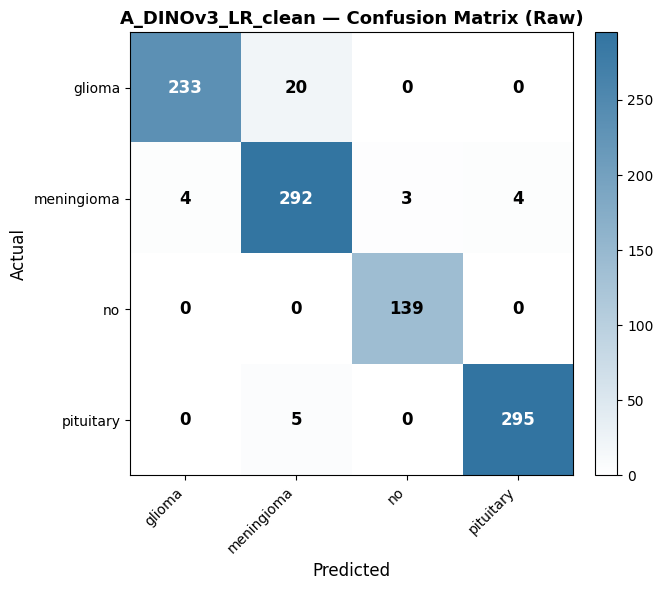

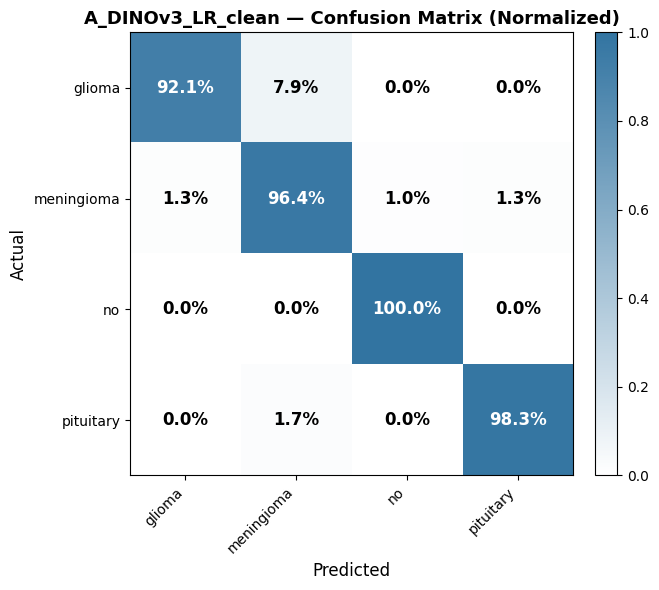

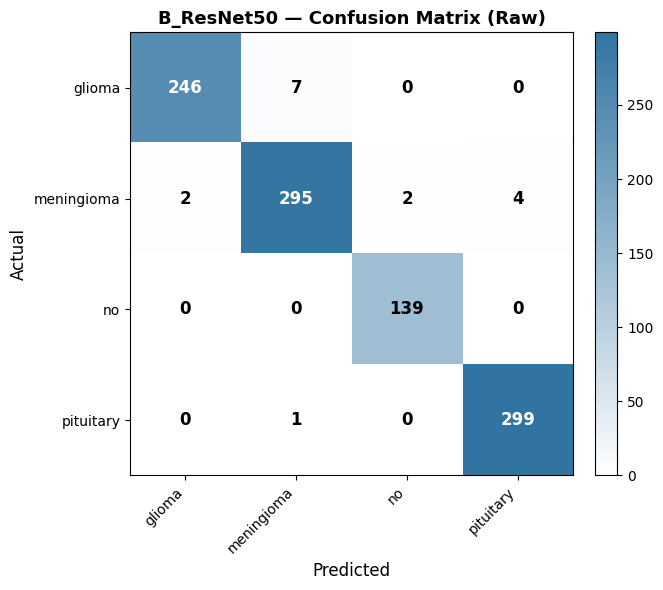

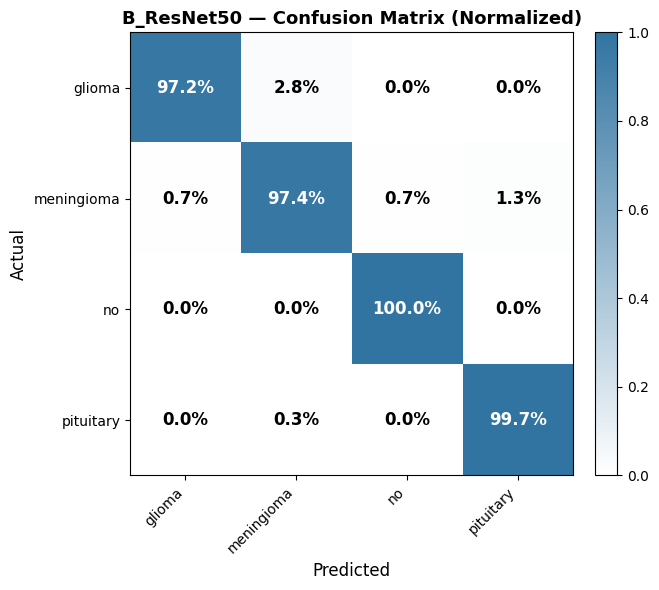

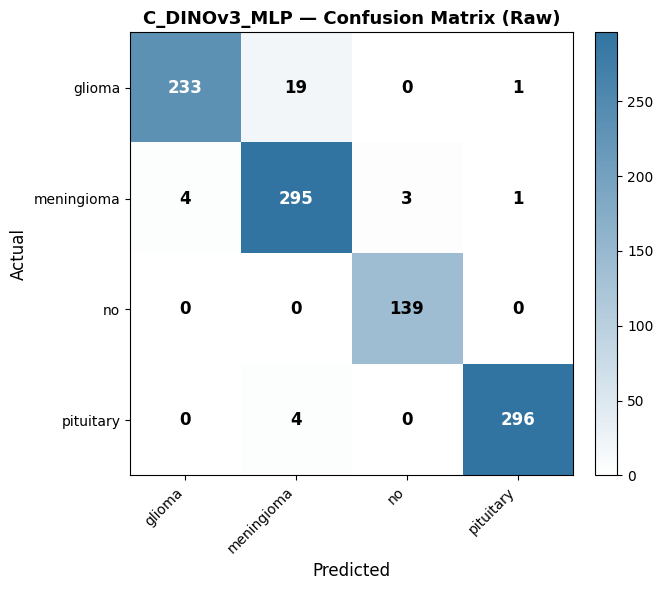

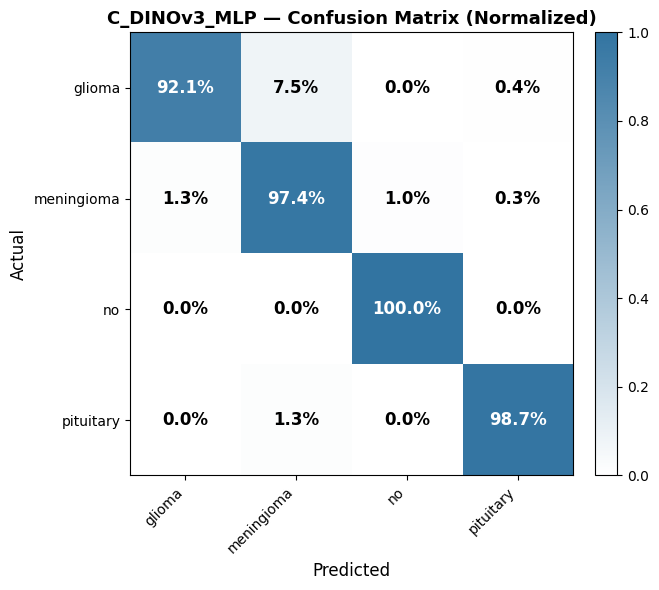

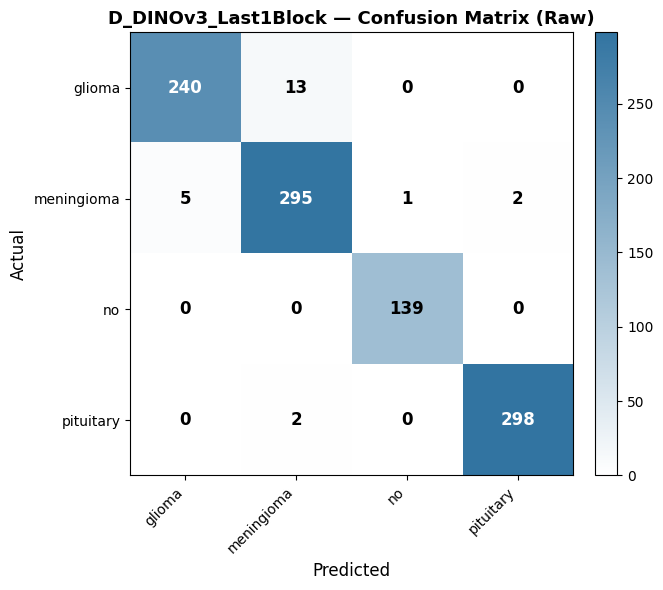

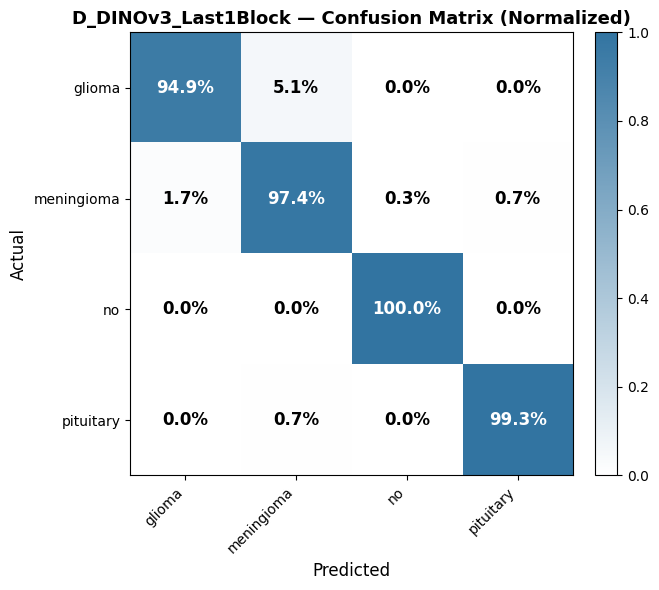

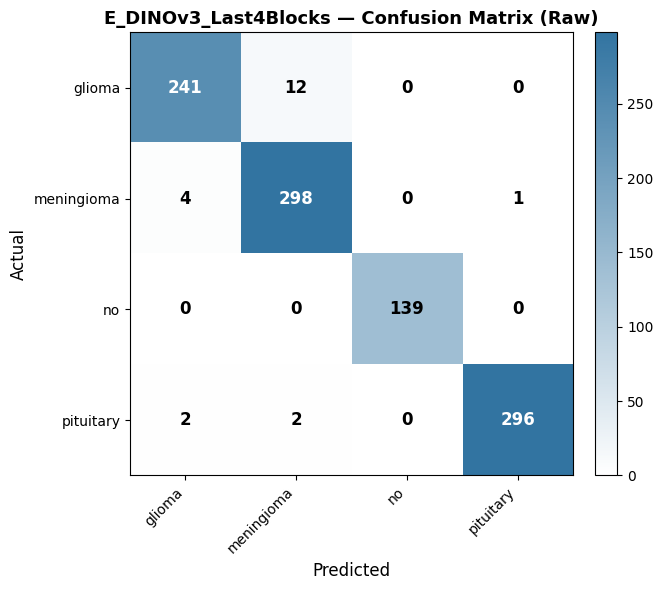

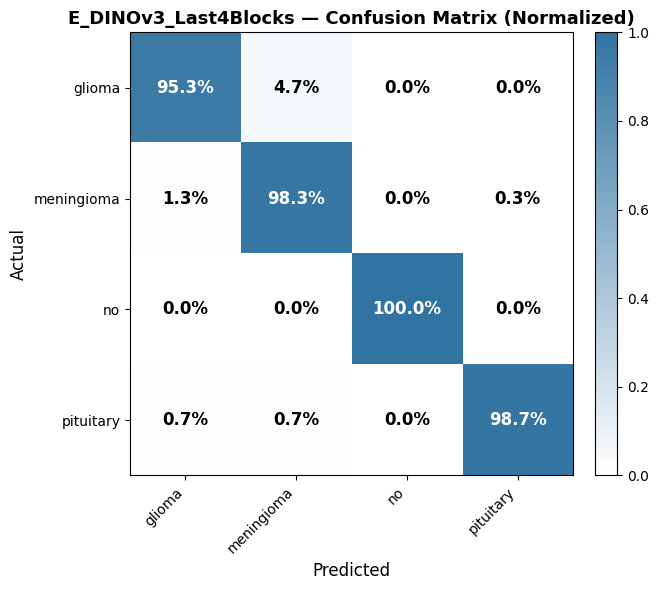

In [28]:
# Collect all model results
all_model_metrics = []
all_model_preds = {}
all_model_probs = {}

# Model A (clean LR)
m_a = dict(clean_test_metrics_lr)
m_a["total_params"] = total_params  # backbone only (LR params negligible)
m_a["trainable_params"] = 0  # backbone frozen; LR is sklearn
m_a["pct_trainable"] = 0.0
all_model_metrics.append(m_a)
all_model_preds["A_DINOv3_LR_clean"] = clean_test_preds_lr
all_model_probs["A_DINOv3_LR_clean"] = clean_test_proba_lr

# Model B (ResNet50)
m_b = dict(resnet_metrics)
m_b["total_params"] = total_resnet
m_b["trainable_params"] = trainable_resnet
m_b["pct_trainable"] = 100.0 * trainable_resnet / total_resnet
all_model_metrics.append(m_b)
all_model_preds["B_ResNet50"] = resnet_preds
all_model_probs["B_ResNet50"] = resnet_probs

# Model C (MLP)
m_c = dict(mlp_metrics)
m_c["total_params"] = total_params + total_mlp
m_c["trainable_params"] = trainable_mlp
m_c["pct_trainable"] = 100.0 * trainable_mlp / (total_params + total_mlp)
all_model_metrics.append(m_c)
all_model_preds["C_DINOv3_MLP"] = mlp_preds
all_model_probs["C_DINOv3_MLP"] = mlp_probs

# Model D (Last-1)
m_d = dict(metrics_d)
m_d["total_params"] = total_d
m_d["trainable_params"] = trainable_d
m_d["pct_trainable"] = 100.0 * trainable_d / total_d
all_model_metrics.append(m_d)
all_model_preds["D_DINOv3_Last1Block"] = preds_d
all_model_probs["D_DINOv3_Last1Block"] = probs_d

# Model E (Last-4)
m_e = dict(metrics_e)
m_e["total_params"] = total_e
m_e["trainable_params"] = trainable_e
m_e["pct_trainable"] = 100.0 * trainable_e / total_e
all_model_metrics.append(m_e)
all_model_preds["E_DINOv3_Last4Blocks"] = preds_e
all_model_probs["E_DINOv3_Last4Blocks"] = probs_e

# Build comparison table
df_comparison = pd.DataFrame(all_model_metrics)
col_order = ["model", "total_params", "trainable_params", "pct_trainable",
             "val_macro_f1", "accuracy", "balanced_accuracy",
             "macro_precision", "macro_recall", "macro_f1",
             "weighted_precision", "weighted_recall", "weighted_f1",
             "kappa", "training_time_s"]
existing_cols = [c for c in col_order if c in df_comparison.columns]
df_comparison = df_comparison[existing_cols]
df_comparison.to_csv(OUT_DIRS["out_comparison"] / "model_comparison_table.csv", index=False)

# Per-class metrics for all models
all_per_class = []
for model_name, pc_df in [
    ("A_DINOv3_LR_clean", clean_per_class_lr),
    ("B_ResNet50", resnet_per_class),
    ("C_DINOv3_MLP", mlp_per_class),
    ("D_DINOv3_Last1Block", per_class_d),
    ("E_DINOv3_Last4Blocks", per_class_e),
]:
    pc = pc_df.copy()
    pc["model"] = model_name
    all_per_class.append(pc)
df_all_per_class = pd.concat(all_per_class, ignore_index=True)
df_all_per_class.to_csv(OUT_DIRS["out_comparison"] / "all_per_class_metrics.csv", index=False)

print("=" * 120)
print("FAIR MODEL COMPARISON TABLE")
print("=" * 120)
print(df_comparison.to_string(index=False))
print(f"\nSaved to {OUT_DIRS['out_comparison'] / 'model_comparison_table.csv'}")

# Confusion matrices for all models
for model_name, preds in all_model_preds.items():
    cm = confusion_matrix(y_clean_test, preds)
    plot_confusion_matrix(cm, CLASS_NAMES,
        f"{model_name} — Confusion Matrix (Raw)",
        str(OUT_DIRS["out_comparison"] / f"{model_name}_confusion_raw"), normalize=False)
    plot_confusion_matrix(cm, CLASS_NAMES,
        f"{model_name} — Confusion Matrix (Normalized)",
        str(OUT_DIRS["out_comparison"] / f"{model_name}_confusion_norm"), normalize=True)

## Section 21 — Model Selection

The final candidate architecture is selected based primarily on **validation macro F1**.  
The model is NOT selected based on test accuracy.

In [29]:
# Select best model by validation macro F1
df_selection = df_comparison[["model", "val_macro_f1", "accuracy", "macro_f1", "kappa"]].copy()
df_selection = df_selection.sort_values("val_macro_f1", ascending=False)

best_model_name = df_selection.iloc[0]["model"]
best_val_f1 = df_selection.iloc[0]["val_macro_f1"]

print("=" * 80)
print("MODEL SELECTION")
print("=" * 80)
print(df_selection.to_string(index=False))
print(f"\nSELECTED MODEL: {best_model_name}")
print(f"Reason: Highest validation macro F1 = {best_val_f1:.4f}")
print("\nSelection was based on validation performance only.")
print("Test set was NOT used for architecture selection.")

# Store selected model predictions and probabilities for downstream use
selected_preds = all_model_preds[best_model_name]
selected_probs = all_model_probs[best_model_name]
selected_metrics = df_comparison[df_comparison["model"] == best_model_name].iloc[0].to_dict()

df_selection.to_csv(OUT_DIRS["out_comparison"] / "model_selection.csv", index=False)

MODEL SELECTION
               model  val_macro_f1  accuracy  macro_f1    kappa
          B_ResNet50      0.988015  0.983920  0.985050 0.978041
E_DINOv3_Last4Blocks      0.983874  0.978894  0.981183 0.971162
 D_DINOv3_Last1Block      0.982679  0.976884  0.979021 0.968419
        C_DINOv3_MLP      0.971694  0.967839  0.970098 0.956057
   A_DINOv3_LR_clean      0.960302  0.963819  0.966814 0.950564

SELECTED MODEL: B_ResNet50
Reason: Highest validation macro F1 = 0.9880

Selection was based on validation performance only.
Test set was NOT used for architecture selection.


## Section 22 — Three-Seed Experiment

Run the key models using seeds 42, 123, and 2026.  
For each seed, recreate the stratified train/validation split from the clean training pool.  
The exact clean test set remains unchanged.

Confidence intervals use the **Student t-distribution** (df=2, t ≈ 4.303 for 95% CI),
not z=1.96.

In [30]:
from scipy.stats import t as t_dist

seed_results_all = []

# Models to run: at minimum A (LR), B (ResNet50), and the selected model
# We will run all 5 if compute is reasonable (LR and MLP are fast)
seed_models_to_run = ["A_DINOv3_LR_clean", "B_ResNet50", "C_DINOv3_MLP"]
# Add selected model if not already in list
if best_model_name not in seed_models_to_run:
    seed_models_to_run.append(best_model_name)

for seed in CONFIG["seeds"]:
    print(f"\n{'='*60}")
    print(f"SEED {seed}")
    print(f"{'='*60}")

    set_seed(seed)

    # Recreate split
    idx_tr_s, idx_va_s = train_test_split(
        list(range(len(clean_train_fps))),
        test_size=CONFIG["val_split"],
        stratify=clean_train_labels_int,
        random_state=seed,
    )

    # --- Model A: LR ---
    X_tr_s = X_clean_all_train[idx_tr_s]
    y_tr_s = y_clean_all_train[idx_tr_s]
    X_va_s = X_clean_all_train[idx_va_s]
    y_va_s = y_clean_all_train[idx_va_s]

    clf_s = LogisticRegression(
        C=CONFIG["C"], solver="lbfgs", max_iter=CONFIG["max_iter"],
        multi_class="multinomial", random_state=seed,
    )
    clf_s.fit(X_tr_s, y_tr_s)
    preds_s = clf_s.predict(X_clean_test)
    m_s = compute_multiclass_metrics(y_clean_test, preds_s, CLASS_NAMES)
    m_s["seed"] = seed
    m_s["model"] = "A_DINOv3_LR_clean"
    seed_results_all.append(m_s)
    print(f"  A_DINOv3_LR: Acc={m_s['accuracy']:.4f}  MacroF1={m_s['macro_f1']:.4f}")

    # --- Model C: MLP (retrain from scratch with different split) ---
    set_seed(seed)
    mlp_s = MLPHead(hidden_dim, 256, NUM_CLASSES, CONFIG["dropout"]).to(device)
    feat_tr_ds = FeatureDataset(X_tr_s, y_tr_s)
    feat_va_ds = FeatureDataset(X_va_s, y_va_s)
    feat_tr_loader = DataLoader(feat_tr_ds, batch_size=CONFIG["batch_size"], shuffle=True)
    feat_va_loader = DataLoader(feat_va_ds, batch_size=CONFIG["batch_size"], shuffle=False)
    opt_s = optim.Adam(mlp_s.parameters(), lr=CONFIG["lr_head"],
                       weight_decay=CONFIG["weight_decay"])
    sch_s = optim.lr_scheduler.ReduceLROnPlateau(opt_s, mode="min", factor=0.5, patience=3)
    mlp_s, _, _ = train_pytorch_model(
        mlp_s, feat_tr_loader, feat_va_loader, opt_s, sch_s,
        criterion, CONFIG["epochs_mlp"], CONFIG["patience"], device, f"MLP-seed{seed}"
    )
    preds_mlp_s, _, _, m_mlp_s, _ = evaluate_pytorch_model(
        mlp_s, feat_test_loader, device, CLASS_NAMES)
    m_mlp_s["seed"] = seed
    m_mlp_s["model"] = "C_DINOv3_MLP"
    seed_results_all.append(m_mlp_s)
    print(f"  C_DINOv3_MLP: Acc={m_mlp_s['accuracy']:.4f}  MacroF1={m_mlp_s['macro_f1']:.4f}")

    # --- Model B: ResNet50 ---
    set_seed(seed)
    resnet_s = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    resnet_s.fc = nn.Linear(resnet_s.fc.in_features, NUM_CLASSES)
    resnet_s = resnet_s.to(device)

    # Rebuild data loaders with new split
    train_fps_s = [clean_train_fps[i] for i in idx_tr_s]
    train_labs_s = [clean_train_labels_int[i] for i in idx_tr_s]
    val_fps_s = [clean_train_fps[i] for i in idx_va_s]
    val_labs_s = [clean_train_labels_int[i] for i in idx_va_s]

    train_ds_s = ImageListDataset(train_fps_s, train_labs_s, transform_minimal)
    val_ds_s = ImageListDataset(val_fps_s, val_labs_s, transform_minimal)
    train_ldr_s = DataLoader(train_ds_s, batch_size=CONFIG["batch_size"], shuffle=True,
                             num_workers=2, pin_memory=True)
    val_ldr_s = DataLoader(val_ds_s, batch_size=CONFIG["batch_size"], shuffle=False,
                           num_workers=2, pin_memory=True)

    opt_r = optim.Adam(resnet_s.parameters(), lr=CONFIG["lr_resnet"],
                       weight_decay=CONFIG["weight_decay"])
    sch_r = optim.lr_scheduler.ReduceLROnPlateau(opt_r, mode="min", factor=0.5, patience=3)
    resnet_s, _, _ = train_pytorch_model(
        resnet_s, train_ldr_s, val_ldr_s, opt_r, sch_r,
        criterion, CONFIG["epochs_resnet"], CONFIG["patience"], device, f"ResNet-seed{seed}"
    )
    preds_r_s, _, _, m_r_s, _ = evaluate_pytorch_model(
        resnet_s, test_loader, device, CLASS_NAMES)
    m_r_s["seed"] = seed
    m_r_s["model"] = "B_ResNet50"
    seed_results_all.append(m_r_s)
    print(f"  B_ResNet50: Acc={m_r_s['accuracy']:.4f}  MacroF1={m_r_s['macro_f1']:.4f}")

    # Clean up GPU memory
    del resnet_s, mlp_s
    torch.cuda.empty_cache()

# Build results table
df_seed_all = pd.DataFrame(seed_results_all)
df_seed_all.to_csv(OUT_DIRS["out_seed"] / "seed_results.csv", index=False)

# Summary with Student-t CI
metric_cols = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "kappa"]
summary_rows = []
n_seeds = len(CONFIG["seeds"])
t_crit = t_dist.ppf(0.975, df=n_seeds - 1)  # ~4.303 for df=2

for model_name in df_seed_all["model"].unique():
    model_data = df_seed_all[df_seed_all["model"] == model_name]
    for col in metric_cols:
        vals = model_data[col].values
        m = vals.mean()
        s = vals.std(ddof=1)
        ci_half = t_crit * s / np.sqrt(n_seeds)
        summary_rows.append({
            "model": model_name, "metric": col,
            "mean": m, "std": s,
            "ci95_lower": m - ci_half, "ci95_upper": m + ci_half,
            "t_critical": t_crit, "df": n_seeds - 1,
        })

df_seed_summary = pd.DataFrame(summary_rows)
df_seed_summary.to_csv(OUT_DIRS["out_seed"] / "seed_summary.csv", index=False)

print("\n" + "=" * 100)
print("THREE-SEED SUMMARY (Student-t 95% CI)")
print("=" * 100)
for model_name in df_seed_all["model"].unique():
    print(f"\n  {model_name}:")
    ms = df_seed_summary[df_seed_summary["model"] == model_name]
    for _, row in ms.iterrows():
        print(f"    {row['metric']}: {row['mean']:.4f} ± {row['std']:.4f}  "
              f"[{row['ci95_lower']:.4f} - {row['ci95_upper']:.4f}]")


SEED 42


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  A_DINOv3_LR: Acc=0.9638  MacroF1=0.9668
  [MLP-seed42] Epoch 1/30  TrainLoss=0.4483  ValLoss=0.2435  ValAcc=0.9113  ValF1=0.9139  *BEST*
  [MLP-seed42] Epoch 2/30  TrainLoss=0.2225  ValLoss=0.2136  ValAcc=0.9261  ValF1=0.9276  *BEST*
  [MLP-seed42] Epoch 3/30  TrainLoss=0.1649  ValLoss=0.1667  ValAcc=0.9422  ValF1=0.9439  *BEST*
  [MLP-seed42] Epoch 5/30  TrainLoss=0.1379  ValLoss=0.2398  ValAcc=0.9032  ValF1=0.9016  
  [MLP-seed42] Epoch 6/30  TrainLoss=0.1173  ValLoss=0.1495  ValAcc=0.9476  ValF1=0.9488  *BEST*
  [MLP-seed42] Epoch 8/30  TrainLoss=0.0932  ValLoss=0.1254  ValAcc=0.9449  ValF1=0.9458  *BEST*
  [MLP-seed42] Epoch 9/30  TrainLoss=0.0929  ValLoss=0.1240  ValAcc=0.9449  ValF1=0.9461  *BEST*
  [MLP-seed42] Epoch 10/30  TrainLoss=0.0879  ValLoss=0.1714  ValAcc=0.9382  ValF1=0.9382  
  [MLP-seed42] Epoch 13/30  TrainLoss=0.0633  ValLoss=0.1115  ValAcc=0.9570  ValF1=0.9574  *BEST*
  [MLP-seed42] Epoch 15/30  TrainLoss=0.0495  ValLoss=0.1139  ValAcc=0.9503  ValF1=0.9506  
  [

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  A_DINOv3_LR: Acc=0.9628  MacroF1=0.9660
  [MLP-seed123] Epoch 1/30  TrainLoss=0.4408  ValLoss=0.3170  ValAcc=0.8790  ValF1=0.8825  *BEST*
  [MLP-seed123] Epoch 2/30  TrainLoss=0.2274  ValLoss=0.2355  ValAcc=0.9059  ValF1=0.9074  *BEST*
  [MLP-seed123] Epoch 3/30  TrainLoss=0.1822  ValLoss=0.1955  ValAcc=0.9220  ValF1=0.9235  *BEST*
  [MLP-seed123] Epoch 4/30  TrainLoss=0.1534  ValLoss=0.1932  ValAcc=0.9261  ValF1=0.9278  *BEST*
  [MLP-seed123] Epoch 5/30  TrainLoss=0.1429  ValLoss=0.1890  ValAcc=0.9234  ValF1=0.9245  *BEST*
  [MLP-seed123] Epoch 6/30  TrainLoss=0.1174  ValLoss=0.1826  ValAcc=0.9261  ValF1=0.9268  *BEST*
  [MLP-seed123] Epoch 7/30  TrainLoss=0.1025  ValLoss=0.1515  ValAcc=0.9422  ValF1=0.9442  *BEST*
  [MLP-seed123] Epoch 8/30  TrainLoss=0.1013  ValLoss=0.1410  ValAcc=0.9409  ValF1=0.9416  *BEST*
  [MLP-seed123] Epoch 9/30  TrainLoss=0.0940  ValLoss=0.1385  ValAcc=0.9435  ValF1=0.9441  *BEST*
  [MLP-seed123] Epoch 10/30  TrainLoss=0.0872  ValLoss=0.1397  ValAcc=0.9489

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  A_DINOv3_LR: Acc=0.9658  MacroF1=0.9692
  [MLP-seed2026] Epoch 1/30  TrainLoss=0.4496  ValLoss=0.2135  ValAcc=0.9288  ValF1=0.9305  *BEST*
  [MLP-seed2026] Epoch 2/30  TrainLoss=0.2301  ValLoss=0.1635  ValAcc=0.9395  ValF1=0.9410  *BEST*
  [MLP-seed2026] Epoch 5/30  TrainLoss=0.1488  ValLoss=0.1688  ValAcc=0.9301  ValF1=0.9310  
  [MLP-seed2026] Epoch 7/30  TrainLoss=0.0940  ValLoss=0.1196  ValAcc=0.9543  ValF1=0.9547  *BEST*
  [MLP-seed2026] Epoch 8/30  TrainLoss=0.0799  ValLoss=0.1146  ValAcc=0.9583  ValF1=0.9592  *BEST*
  [MLP-seed2026] Epoch 10/30  TrainLoss=0.0673  ValLoss=0.1243  ValAcc=0.9516  ValF1=0.9519  
  [MLP-seed2026] Epoch 13/30  TrainLoss=0.0444  ValLoss=0.1129  ValAcc=0.9583  ValF1=0.9586  *BEST*
  [MLP-seed2026] Epoch 15/30  TrainLoss=0.0396  ValLoss=0.1117  ValAcc=0.9570  ValF1=0.9575  *BEST*
  [MLP-seed2026] Epoch 20/30  TrainLoss=0.0283  ValLoss=0.1159  ValAcc=0.9556  ValF1=0.9560  
  [MLP-seed2026] Epoch 22/30  TrainLoss=0.0273  ValLoss=0.1109  ValAcc=0.9597  Va

## Section 23 — Five-Fold Stratified Cross-Validation

Five-fold stratified CV is performed **only on the clean training pool**.  
The clean test set never enters cross-validation.

Cross-validation is stratified at the **image level**; patient-level grouping cannot be guaranteed
because reliable patient identifiers are unavailable.

In [31]:
skf = StratifiedKFold(n_splits=CONFIG["n_folds"], shuffle=True, random_state=42)

cv_results_all = []
cv_models_to_run = ["A_DINOv3_LR_clean"]
if best_model_name not in cv_models_to_run:
    cv_models_to_run.append(best_model_name)

# Cross-validation for LR (uses pre-extracted features)
print("Running 5-fold CV for Frozen DINOv3 + LR...")
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_clean_all_train, y_clean_all_train), 1):
    X_tr_cv, y_tr_cv = X_clean_all_train[tr_idx], y_clean_all_train[tr_idx]
    X_va_cv, y_va_cv = X_clean_all_train[va_idx], y_clean_all_train[va_idx]

    clf_cv = LogisticRegression(
        C=CONFIG["C"], solver="lbfgs", max_iter=CONFIG["max_iter"],
        multi_class="multinomial", random_state=42,
    )
    clf_cv.fit(X_tr_cv, y_tr_cv)
    preds_cv = clf_cv.predict(X_va_cv)
    m_cv = compute_multiclass_metrics(y_va_cv, preds_cv, CLASS_NAMES)
    m_cv["fold"] = fold
    m_cv["model"] = "A_DINOv3_LR_clean"
    cv_results_all.append(m_cv)
    print(f"  Fold {fold}: Acc={m_cv['accuracy']:.4f}  MacroF1={m_cv['macro_f1']:.4f}")

# Cross-validation for MLP (uses pre-extracted features — fast)
if "C_DINOv3_MLP" in cv_models_to_run or best_model_name == "C_DINOv3_MLP":
    print("\nRunning 5-fold CV for Frozen DINOv3 + MLP...")
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_clean_all_train, y_clean_all_train), 1):
        set_seed(42)
        X_tr_cv, y_tr_cv = X_clean_all_train[tr_idx], y_clean_all_train[tr_idx]
        X_va_cv, y_va_cv = X_clean_all_train[va_idx], y_clean_all_train[va_idx]

        mlp_cv = MLPHead(hidden_dim, 256, NUM_CLASSES, CONFIG["dropout"]).to(device)
        ds_tr_cv = FeatureDataset(X_tr_cv, y_tr_cv)
        ds_va_cv = FeatureDataset(X_va_cv, y_va_cv)
        ldr_tr_cv = DataLoader(ds_tr_cv, batch_size=CONFIG["batch_size"], shuffle=True)
        ldr_va_cv = DataLoader(ds_va_cv, batch_size=CONFIG["batch_size"], shuffle=False)
        opt_cv = optim.Adam(mlp_cv.parameters(), lr=CONFIG["lr_head"],
                            weight_decay=CONFIG["weight_decay"])
        sch_cv = optim.lr_scheduler.ReduceLROnPlateau(opt_cv, mode="min", factor=0.5, patience=3)
        mlp_cv, _, _ = train_pytorch_model(
            mlp_cv, ldr_tr_cv, ldr_va_cv, opt_cv, sch_cv,
            criterion, CONFIG["epochs_mlp"], CONFIG["patience"], device, f"MLP-fold{fold}"
        )
        preds_mlp_cv, _, labels_mlp_cv, m_mlp_cv, _ = evaluate_pytorch_model(
            mlp_cv, ldr_va_cv, device, CLASS_NAMES)
        m_mlp_cv["fold"] = fold
        m_mlp_cv["model"] = "C_DINOv3_MLP"
        cv_results_all.append(m_mlp_cv)
        print(f"  Fold {fold}: Acc={m_mlp_cv['accuracy']:.4f}  MacroF1={m_mlp_cv['macro_f1']:.4f}")
        del mlp_cv
        torch.cuda.empty_cache()

# Build CV summary
df_cv_all = pd.DataFrame(cv_results_all)
df_cv_all.to_csv(OUT_DIRS["out_cv"] / "cv_fold_results.csv", index=False)

cv_summary_rows = []
n_folds = CONFIG["n_folds"]
t_crit_cv = t_dist.ppf(0.975, df=n_folds - 1)
metric_cols_cv = ["accuracy", "balanced_accuracy", "macro_precision", "macro_recall",
                  "macro_f1", "weighted_f1", "kappa"]

for model_name in df_cv_all["model"].unique():
    model_data = df_cv_all[df_cv_all["model"] == model_name]
    for col in metric_cols_cv:
        vals = model_data[col].values
        m = vals.mean()
        s = vals.std(ddof=1)
        ci_half = t_crit_cv * s / np.sqrt(n_folds)
        cv_summary_rows.append({
            "model": model_name, "metric": col,
            "mean": m, "std": s,
            "ci95_lower": m - ci_half, "ci95_upper": m + ci_half,
            "t_critical": t_crit_cv, "df": n_folds - 1,
        })

df_cv_summary = pd.DataFrame(cv_summary_rows)
df_cv_summary.to_csv(OUT_DIRS["out_cv"] / "cv_summary.csv", index=False)

print("\n" + "=" * 100)
print("FIVE-FOLD CV SUMMARY (Student-t 95% CI)")
print("=" * 100)
for model_name in df_cv_all["model"].unique():
    print(f"\n  {model_name}:")
    ms = df_cv_summary[df_cv_summary["model"] == model_name]
    for _, row in ms.iterrows():
        print(f"    {row['metric']}: {row['mean']:.4f} ± {row['std']:.4f}  "
              f"[{row['ci95_lower']:.4f} - {row['ci95_upper']:.4f}]")

print("\nCross-validation is stratified at the image level.")
print("Patient-level grouping cannot be guaranteed (patient IDs unavailable).")

Running 5-fold CV for Frozen DINOv3 + LR...


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Fold 1: Acc=0.9606  MacroF1=0.9614


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Fold 2: Acc=0.9576  MacroF1=0.9577


...

  Fold 3: Acc=0.9677  MacroF1=0.9684


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Fold 4: Acc=0.9506  MacroF1=0.9508


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Fold 5: Acc=0.9697  MacroF1=0.9702

FIVE-FOLD CV SUMMARY (Student-t 95% CI)

  A_DINOv3_LR_clean:
    accuracy: 0.9613 ± 0.0078  [0.9516 - 0.9709]
    balanced_accuracy: 0.9612 ± 0.0079  [0.9514 - 0.9710]
    macro_precision: 0.9625 ± 0.0080  [0.9526 - 0.9724]
    macro_recall: 0.9612 ± 0.0079  [0.9514 - 0.9710]
    macro_f1: 0.9617 ± 0.0079  [0.9519 - 0.9716]
    weighted_f1: 0.9613 ± 0.0078  [0.9516 - 0.9710]
    kappa: 0.9481 ± 0.0104  [0.9351 - 0.9610]

Cross-validation is stratified at the image level.
Patient-level grouping cannot be guaranteed (patient IDs unavailable).


## Section 24 — Augmentation Ablation

Augmentation ablation is performed on the selected best DINOv3 adaptation model
using the same clean data split.

Three conditions:
1. **Minimal** — resize + tensor + normalize (same as main comparison)
2. **Conservative MRI** — small rotation, translation, scale
3. **Aggressive** — reproduce original paper's aggressive pipeline

In [32]:
# Determine which model to use for augmentation ablation.
# This loop can ONLY build a DINOv3Classifier with a partially-unfrozen backbone
# (see below), so it is only valid for the DINOv3 fine-tuning variants (D or E).
# If the selected model is anything else (LR, MLP head, or ResNet50), we must
# redirect to the best DINOv3 fine-tuning variant instead of silently mislabeling
# a DINOv3 run with the selected model's name.
DINOV3_FINETUNE_MODELS = ["D_DINOv3_Last1Block", "E_DINOv3_Last4Blocks"]
aug_model_name = best_model_name
if aug_model_name not in DINOV3_FINETUNE_MODELS:
    # Pick the best fine-tuning model (D or E) by val F1
    ft_models = df_comparison[df_comparison["model"].isin(DINOV3_FINETUNE_MODELS)]
    if len(ft_models) > 0:
        aug_model_name = ft_models.sort_values("val_macro_f1", ascending=False).iloc[0]["model"]
    else:
        raise RuntimeError(
            "No DINOv3 fine-tuning variant (D or E) found in df_comparison; "
            "cannot run augmentation ablation, which only supports those architectures."
        )

print(f"Selected overall model: {best_model_name}")
print(f"Augmentation ablation model (DINOv3 fine-tune variant): {aug_model_name}")

aug_conditions = {
    "minimal": transform_minimal,
    "conservative_mri": transform_conservative,
    "aggressive_original": transform_aggressive,
}

aug_results = []

for cond_name, transform_cond in aug_conditions.items():
    print(f"\n{'='*60}")
    print(f"AUGMENTATION CONDITION: {cond_name}")
    print(f"{'='*60}")

    set_seed(42)

    # Determine number of blocks to unfreeze
    if aug_model_name == "E_DINOv3_Last4Blocks":
        n_unfreeze = 4
    elif aug_model_name == "D_DINOv3_Last1Block":
        n_unfreeze = 1
    else:
        raise ValueError(
            f"Unexpected aug_model_name={aug_model_name!r}; augmentation ablation only "
            "supports D_DINOv3_Last1Block or E_DINOv3_Last4Blocks. Refusing to silently "
            "default to 4 unfrozen blocks under the wrong label."
        )

    bb = AutoModel.from_pretrained(CONFIG["model_id"], token=HF_TOKEN).to(device)
    aug_model = DINOv3Classifier(bb, hidden_dim, NUM_CLASSES, CONFIG["dropout"]).to(device)
    unfreeze_last_n_blocks(aug_model, n_unfreeze)

    backbone_p = [p for n, p in aug_model.named_parameters()
                  if "head" not in n and p.requires_grad]
    head_p = list(aug_model.head.parameters())
    opt_aug = optim.Adam([
        {"params": backbone_p, "lr": CONFIG["lr_backbone"]},
        {"params": head_p, "lr": CONFIG["lr_head"]},
    ], weight_decay=CONFIG["weight_decay"])
    sch_aug = optim.lr_scheduler.ReduceLROnPlateau(opt_aug, mode="min", factor=0.5, patience=3)

    # Train with augmented data (augmentation only applied to training)
    train_ds_aug = ImageListDataset(train_fps, train_labs, transform_cond)
    val_ds_aug = ImageListDataset(val_fps, val_labs, transform_minimal)  # Val always minimal
    test_ds_aug = ImageListDataset(test_fps, test_labs, transform_minimal)

    train_ldr_aug = DataLoader(train_ds_aug, batch_size=CONFIG["batch_size"], shuffle=True,
                               num_workers=2, pin_memory=True)
    val_ldr_aug = DataLoader(val_ds_aug, batch_size=CONFIG["batch_size"], shuffle=False,
                             num_workers=2, pin_memory=True)
    test_ldr_aug = DataLoader(test_ds_aug, batch_size=CONFIG["batch_size"], shuffle=False,
                              num_workers=2, pin_memory=True)

    aug_model, hist_aug, best_f1_aug = train_pytorch_model(
        aug_model, train_ldr_aug, val_ldr_aug, opt_aug, sch_aug,
        criterion, CONFIG["epochs_finetune"], CONFIG["patience"], device,
        f"Aug-{cond_name}"
    )

    # Evaluate
    preds_aug, probs_aug, labels_aug, m_aug, pc_aug = evaluate_pytorch_model(
        aug_model, test_ldr_aug, device, CLASS_NAMES
    )
    m_aug["condition"] = cond_name
    m_aug["model"] = aug_model_name
    m_aug["val_macro_f1"] = best_f1_aug
    aug_results.append(m_aug)

    print(f"  Val F1: {best_f1_aug:.4f}")
    for k in ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "kappa"]:
        print(f"  Test {k}: {m_aug[k]:.4f}")

    del aug_model, bb
    torch.cuda.empty_cache()

df_aug = pd.DataFrame(aug_results)
df_aug.to_csv(OUT_DIRS["out_aug"] / "augmentation_ablation.csv", index=False)

print("\n" + "=" * 80)
print("AUGMENTATION ABLATION SUMMARY")
print("=" * 80)
print(df_aug.to_string(index=False))
print(f"\nSaved to {OUT_DIRS['out_aug'] / 'augmentation_ablation.csv'}")
print("\nAugmentation was NOT tuned after reviewing test performance.")

Selected overall model: B_ResNet50
Augmentation ablation model (DINOv3 fine-tune variant): E_DINOv3_Last4Blocks

AUGMENTATION CONDITION: minimal


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Unfroze blocks 8 to 11.
  [Aug-minimal] Epoch 1/25  TrainLoss=0.3578  ValLoss=0.1404  ValAcc=0.9530  ValF1=0.9541  *BEST*
  [Aug-minimal] Epoch 2/25  TrainLoss=0.1019  ValLoss=0.1062  ValAcc=0.9570  ValF1=0.9577  *BEST*
  [Aug-minimal] Epoch 3/25  TrainLoss=0.0390  ValLoss=0.0762  ValAcc=0.9704  ValF1=0.9706  *BEST*
  [Aug-minimal] Epoch 4/25  TrainLoss=0.0159  ValLoss=0.0658  ValAcc=0.9839  ValF1=0.9839  *BEST*
  [Aug-minimal] Epoch 5/25  TrainLoss=0.0067  ValLoss=0.0711  ValAcc=0.9758  ValF1=0.9759  
  [Aug-minimal] Epoch 10/25  TrainLoss=0.0004  ValLoss=0.0703  ValAcc=0.9852  ValF1=0.9852  
  Early stopping at epoch 11 (patience=7)
  Val F1: 0.9839
  Test accuracy: 0.9789
  Test balanced_accuracy: 0.9807
  Test macro_f1: 0.9812
  Test weighted_f1: 0.9789
  Test kappa: 0.9712

AUGMENTATION CONDITION: conservative_mri


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Unfroze blocks 8 to 11.
  [Aug-conservative_mri] Epoch 1/25  TrainLoss=0.3884  ValLoss=0.2161  ValAcc=0.9180  ValF1=0.9211  *BEST*
  [Aug-conservative_mri] Epoch 2/25  TrainLoss=0.1367  ValLoss=0.1169  ValAcc=0.9543  ValF1=0.9554  *BEST*
  [Aug-conservative_mri] Epoch 4/25  TrainLoss=0.0548  ValLoss=0.0732  ValAcc=0.9704  ValF1=0.9707  *BEST*
  [Aug-conservative_mri] Epoch 5/25  TrainLoss=0.0389  ValLoss=0.0805  ValAcc=0.9691  ValF1=0.9693  
  [Aug-conservative_mri] Epoch 8/25  TrainLoss=0.0198  ValLoss=0.0603  ValAcc=0.9812  ValF1=0.9812  *BEST*
  [Aug-conservative_mri] Epoch 10/25  TrainLoss=0.0137  ValLoss=0.0805  ValAcc=0.9812  ValF1=0.9813  
  [Aug-conservative_mri] Epoch 15/25  TrainLoss=0.0077  ValLoss=0.0726  ValAcc=0.9812  ValF1=0.9812  
  Early stopping at epoch 15 (patience=7)
  Val F1: 0.9812
  Test accuracy: 0.9829
  Test balanced_accuracy: 0.9842
  Test macro_f1: 0.9847
  Test weighted_f1: 0.9829
  Test kappa: 0.9767

AUGMENTATION CONDITION: aggressive_original


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Unfroze blocks 8 to 11.
  [Aug-aggressive_original] Epoch 1/25  TrainLoss=0.4611  ValLoss=0.2176  ValAcc=0.9194  ValF1=0.9204  *BEST*
  [Aug-aggressive_original] Epoch 2/25  TrainLoss=0.2010  ValLoss=0.1227  ValAcc=0.9583  ValF1=0.9596  *BEST*
  [Aug-aggressive_original] Epoch 3/25  TrainLoss=0.1444  ValLoss=0.0927  ValAcc=0.9677  ValF1=0.9684  *BEST*
  [Aug-aggressive_original] Epoch 4/25  TrainLoss=0.1435  ValLoss=0.0838  ValAcc=0.9704  ValF1=0.9708  *BEST*
  [Aug-aggressive_original] Epoch 5/25  TrainLoss=0.1036  ValLoss=0.0692  ValAcc=0.9731  ValF1=0.9739  *BEST*
  [Aug-aggressive_original] Epoch 6/25  TrainLoss=0.0972  ValLoss=0.0650  ValAcc=0.9758  ValF1=0.9763  *BEST*
  [Aug-aggressive_original] Epoch 9/25  TrainLoss=0.0775  ValLoss=0.0603  ValAcc=0.9785  ValF1=0.9787  *BEST*
  [Aug-aggressive_original] Epoch 10/25  TrainLoss=0.0661  ValLoss=0.0600  ValAcc=0.9812  ValF1=0.9814  *BEST*
  [Aug-aggressive_original] Epoch 11/25  TrainLoss=0.0614  ValLoss=0.0555  ValAcc=0.9812  ValF1

## Section 25 — Calibration Experiment

For the important models, compute:
- Expected Calibration Error (ECE)
- Brier score
- Negative log-likelihood (NLL)

Generate reliability diagrams.


A_DINOv3_LR_clean:
  ECE:   0.0074
  Brier: 0.0134
  NLL:   0.1026


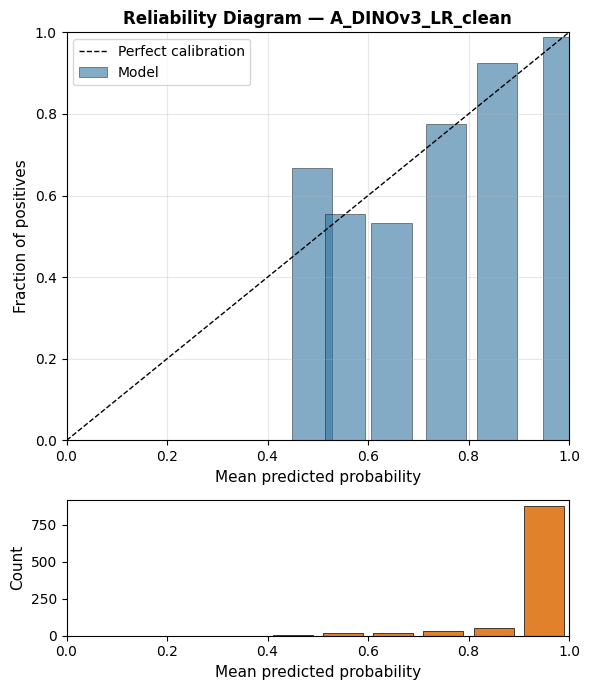


B_ResNet50:
  ECE:   0.0085
  Brier: 0.0057
  NLL:   0.0588


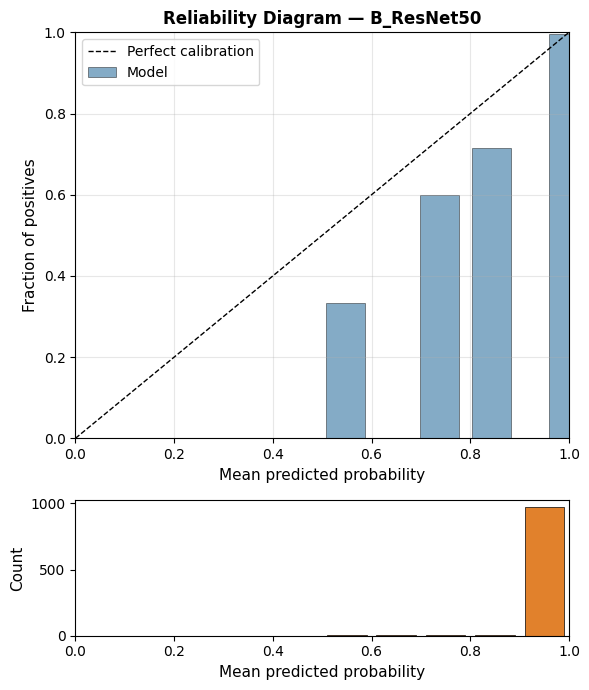


Saved to results_calibration/calibration_metrics.csv


In [33]:
def expected_calibration_error(y_true, y_proba, n_bins=10):
    """Compute Expected Calibration Error (ECE)."""
    confidences = np.max(y_proba, axis=1)
    predictions = np.argmax(y_proba, axis=1)
    accuracies = (predictions == y_true).astype(float)

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    bin_data = []

    for i in range(n_bins):
        lo, hi = bin_boundaries[i], bin_boundaries[i + 1]
        mask = (confidences > lo) & (confidences <= hi)
        if mask.sum() == 0:
            bin_data.append({"bin_lo": lo, "bin_hi": hi, "count": 0,
                             "avg_confidence": 0, "avg_accuracy": 0})
            continue
        bin_acc = accuracies[mask].mean()
        bin_conf = confidences[mask].mean()
        bin_count = mask.sum()
        ece += (bin_count / len(y_true)) * abs(bin_acc - bin_conf)
        bin_data.append({"bin_lo": lo, "bin_hi": hi, "count": int(bin_count),
                         "avg_confidence": float(bin_conf), "avg_accuracy": float(bin_acc)})

    return ece, bin_data


def compute_brier_multiclass(y_true, y_proba):
    """Compute multi-class Brier score (one-vs-rest average)."""
    n_classes = y_proba.shape[1]
    brier = 0.0
    for c in range(n_classes):
        y_bin = (y_true == c).astype(int)
        brier += brier_score_loss(y_bin, y_proba[:, c])
    return brier / n_classes


def compute_nll(y_true, y_proba, eps=1e-12):
    """Compute mean negative log-likelihood of the correct class."""
    y_proba_clipped = np.clip(y_proba, eps, 1 - eps)
    nll = -np.log(y_proba_clipped[np.arange(len(y_true)), y_true]).mean()
    return nll


def plot_reliability_diagram(bin_data, title, save_path):
    """Plot a reliability diagram."""
    bins_with_data = [b for b in bin_data if b["count"] > 0]
    if not bins_with_data:
        print(f"  No bins with data for {title}")
        return

    confs = [b["avg_confidence"] for b in bins_with_data]
    accs = [b["avg_accuracy"] for b in bins_with_data]
    counts = [b["count"] for b in bins_with_data]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 7),
                                    gridspec_kw={"height_ratios": [3, 1]})

    # Reliability plot
    ax1.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
    ax1.bar(confs, accs, width=0.08, alpha=0.6, color="#3274a1", edgecolor="black",
            linewidth=0.5, label="Model")
    ax1.set_xlabel("Mean predicted probability", fontsize=11)
    ax1.set_ylabel("Fraction of positives", fontsize=11)
    ax1.set_title(title, fontsize=12, fontweight="bold")
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Histogram
    bin_edges = np.linspace(0, 1, 11)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    hist_counts = np.zeros(10)
    for b in bin_data:
        idx = min(int(b["avg_confidence"] * 10), 9) if b["count"] > 0 else 0
        hist_counts[idx] = b["count"]
    ax2.bar(bin_centers, hist_counts, width=0.08, color="#e1812c", edgecolor="black",
            linewidth=0.5)
    ax2.set_xlabel("Mean predicted probability", fontsize=11)
    ax2.set_ylabel("Count", fontsize=11)
    ax2.set_xlim(0, 1)

    plt.tight_layout()
    for ext in ["png", "pdf"]:
        fig.savefig(f"{save_path}.{ext}", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# Compute calibration for key models
cal_models = {
    "A_DINOv3_LR_clean": (y_clean_test, clean_test_proba_lr),
    "B_ResNet50": (y_clean_test, resnet_probs),
}
# Add selected model
if best_model_name not in cal_models:
    cal_models[best_model_name] = (y_clean_test, selected_probs)

cal_results = []
for model_name, (y_true, y_proba) in cal_models.items():
    y_true_arr = np.array(y_true)
    ece, bin_data = expected_calibration_error(y_true_arr, y_proba)
    brier = compute_brier_multiclass(y_true_arr, y_proba)
    nll = compute_nll(y_true_arr, y_proba)

    cal_results.append({
        "model": model_name, "ECE": ece, "Brier": brier, "NLL": nll,
    })

    print(f"\n{model_name}:")
    print(f"  ECE:   {ece:.4f}")
    print(f"  Brier: {brier:.4f}")
    print(f"  NLL:   {nll:.4f}")

    plot_reliability_diagram(
        bin_data, f"Reliability Diagram — {model_name}",
        str(OUT_DIRS["out_cal"] / f"reliability_{model_name}")
    )

df_cal = pd.DataFrame(cal_results)
df_cal.to_csv(OUT_DIRS["out_cal"] / "calibration_metrics.csv", index=False)
print(f"\nSaved to {OUT_DIRS['out_cal'] / 'calibration_metrics.csv'}")

## Section 26 — Statistical Comparison

**McNemar's test**: Paired comparison of classification errors between models.  
**Bootstrap CI**: 2000-resample image-level bootstrap for accuracy, balanced accuracy, macro F1.

These are **image-level** bootstrap intervals because patient identifiers are unavailable.

In [34]:
# --- McNemar's test ----------------------------------------------------------
def mcnemar_test(y_true, preds_a, preds_b, model_a_name, model_b_name):
    """Perform McNemar's test between two models."""
    correct_a = (preds_a == y_true)
    correct_b = (preds_b == y_true)
    # b01: A correct, B wrong; b10: A wrong, B correct
    b01 = ((correct_a) & (~correct_b)).sum()
    b10 = ((~correct_a) & (correct_b)).sum()

    # Use exact binomial test for small counts, chi-squared otherwise
    n_discordant = b01 + b10
    if n_discordant < 25:
        # Exact binomial
        p_value = stats.binom_test(b01, n_discordant, 0.5)
        test_type = "exact_binomial"
    else:
        # Chi-squared with continuity correction
        chi2 = (abs(b01 - b10) - 1)**2 / (b01 + b10)
        p_value = 1 - stats.chi2.cdf(chi2, df=1)
        test_type = "chi_squared"

    return {
        "model_a": model_a_name, "model_b": model_b_name,
        "b01_a_right_b_wrong": int(b01), "b10_a_wrong_b_right": int(b10),
        "n_discordant": int(n_discordant),
        "p_value": p_value, "test_type": test_type,
        "significant_p005": p_value < 0.05,
    }


y_true_test = np.array(y_clean_test)
stat_results = []

# DINOv3 LR vs selected model
if best_model_name != "A_DINOv3_LR_clean":
    result = mcnemar_test(y_true_test, clean_test_preds_lr, selected_preds,
                          "A_DINOv3_LR_clean", best_model_name)
    stat_results.append(result)
    print(f"McNemar: A_DINOv3_LR vs {best_model_name}: p={result['p_value']:.4f} "
          f"({'significant' if result['significant_p005'] else 'not significant'})")

# ResNet50 vs selected model
if best_model_name != "B_ResNet50":
    result = mcnemar_test(y_true_test, resnet_preds, selected_preds,
                          "B_ResNet50", best_model_name)
    stat_results.append(result)
    print(f"McNemar: B_ResNet50 vs {best_model_name}: p={result['p_value']:.4f} "
          f"({'significant' if result['significant_p005'] else 'not significant'})")

# --- Bootstrap confidence intervals ------------------------------------------
rng_boot = np.random.RandomState(42)

def bootstrap_ci(y_true, y_pred, metric_fn, n_boot=CONFIG["n_bootstrap"], ci=0.95):
    scores = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng_boot.randint(0, n, n)
        try:
            scores.append(metric_fn(y_true[idx], y_pred[idx]))
        except Exception:
            continue
    scores = np.array(scores)
    alpha = (1 - ci) / 2
    return np.percentile(scores, 100 * alpha), np.percentile(scores, 100 * (1 - alpha))

boot_results = []
for model_name, preds in [
    ("A_DINOv3_LR_clean", clean_test_preds_lr),
    ("B_ResNet50", resnet_preds),
    (best_model_name, selected_preds),
]:
    preds_arr = np.array(preds)
    for metric_name, fn in [
        ("accuracy", accuracy_score),
        ("balanced_accuracy", balanced_accuracy_score),
        ("macro_f1", lambda yt, yp: f1_score(yt, yp, average="macro", zero_division=0)),
    ]:
        pt = fn(y_true_test, preds_arr)
        lo, hi = bootstrap_ci(y_true_test, preds_arr, fn)
        boot_results.append({
            "model": model_name, "metric": metric_name,
            "point_estimate": pt, "ci95_lower": lo, "ci95_upper": hi,
        })
        print(f"  {model_name} {metric_name}: {pt:.4f} [{lo:.4f} - {hi:.4f}]")

df_stat = pd.DataFrame(stat_results)
df_boot = pd.DataFrame(boot_results)
df_stat.to_csv(OUT_DIRS["out_comparison"] / "mcnemar_results.csv", index=False)
df_boot.to_csv(OUT_DIRS["out_comparison"] / "bootstrap_confidence_intervals.csv", index=False)

print("\nThese are IMAGE-LEVEL bootstrap confidence intervals.")
print("Patient identifiers are unavailable — patient-level independence cannot be verified.")
print(f"Saved to {OUT_DIRS['out_comparison']}")

McNemar: A_DINOv3_LR vs B_ResNet50: p=0.0042 (significant)
  A_DINOv3_LR_clean accuracy: 0.9638 [0.9518 - 0.9749]
  A_DINOv3_LR_clean balanced_accuracy: 0.9670 [0.9563 - 0.9773]
  A_DINOv3_LR_clean macro_f1: 0.9668 [0.9564 - 0.9774]
  B_ResNet50 accuracy: 0.9839 [0.9759 - 0.9910]
  B_ResNet50 balanced_accuracy: 0.9856 [0.9786 - 0.9924]
  B_ResNet50 macro_f1: 0.9850 [0.9770 - 0.9917]
  B_ResNet50 accuracy: 0.9839 [0.9759 - 0.9910]
  B_ResNet50 balanced_accuracy: 0.9856 [0.9784 - 0.9922]
  B_ResNet50 macro_f1: 0.9850 [0.9770 - 0.9919]

These are IMAGE-LEVEL bootstrap confidence intervals.
Patient identifiers are unavailable — patient-level independence cannot be verified.
Saved to results_model_comparison


## Section 27 — Publication Figures

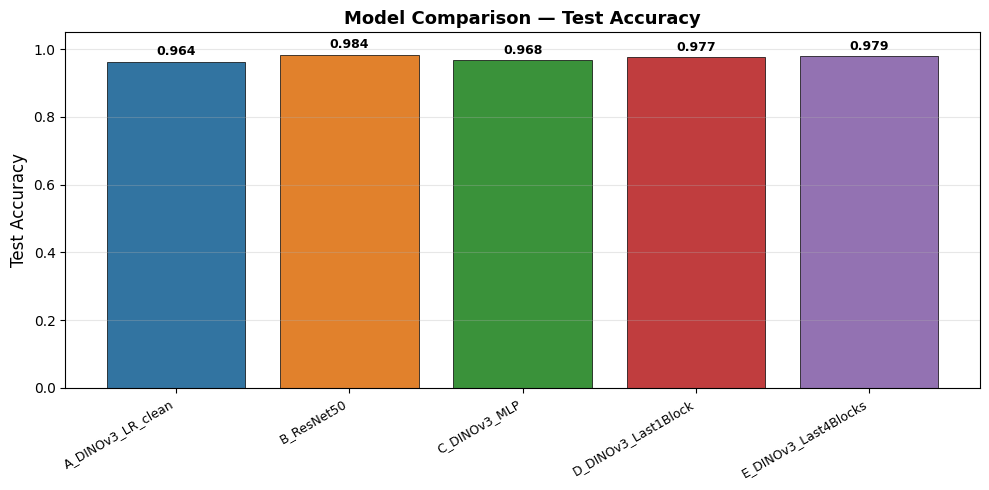

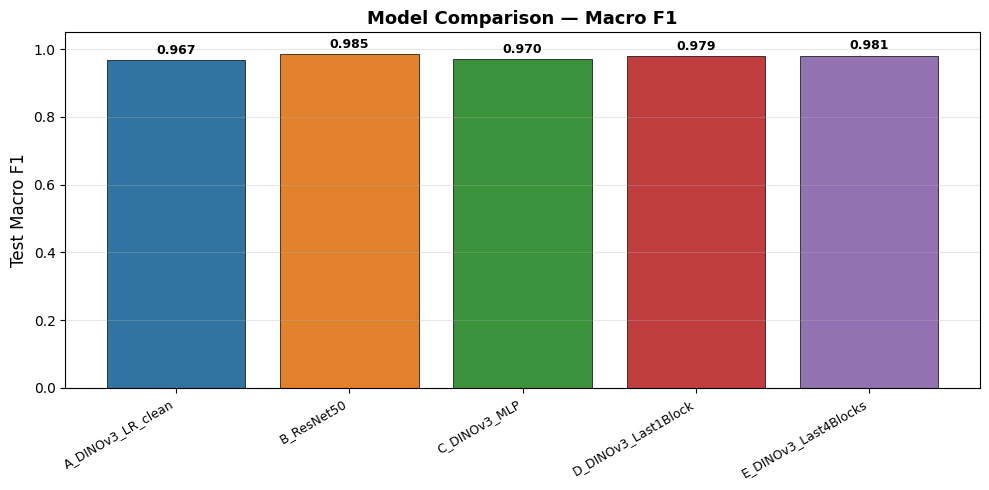

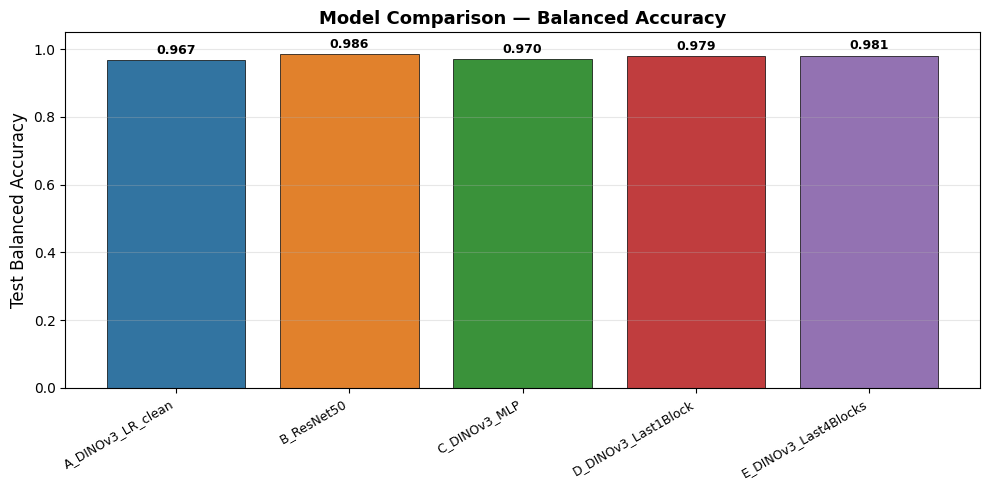

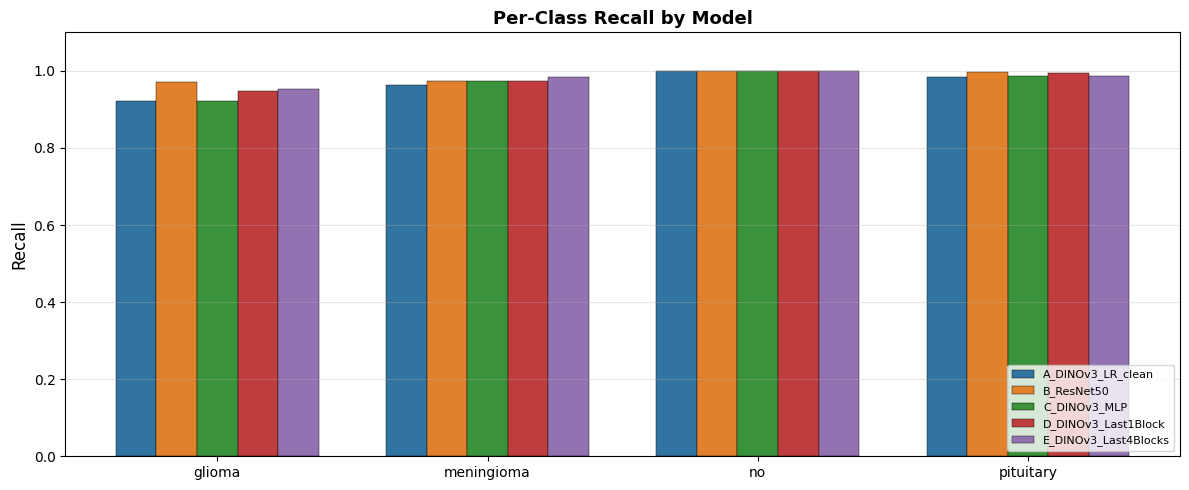

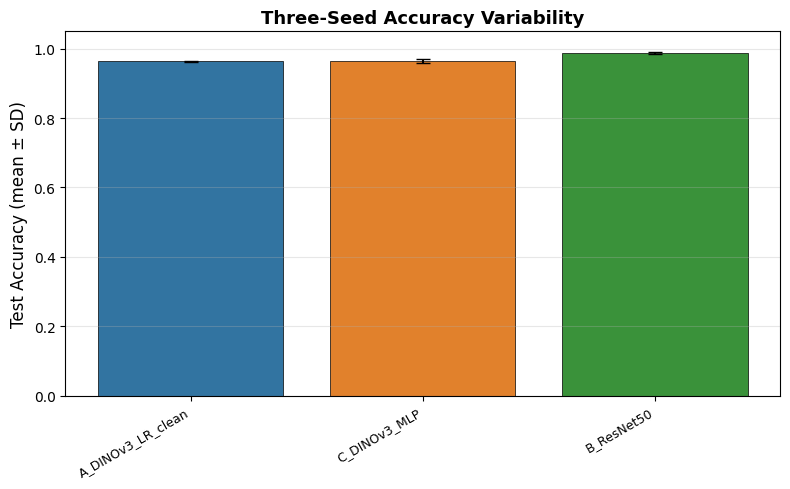

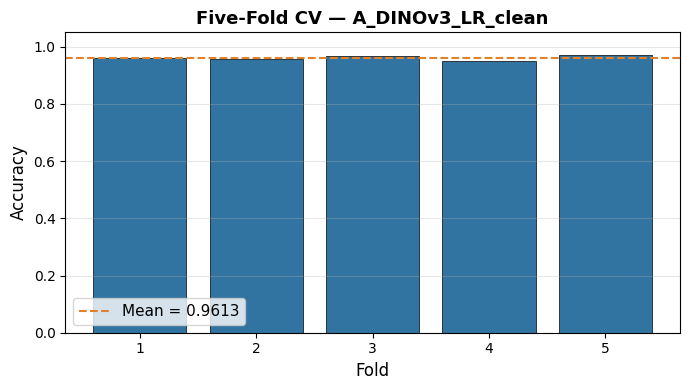

All publication figures saved as PNG and PDF.


In [35]:
# --- 1. Model Accuracy Comparison Bar Chart ---------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
model_names = df_comparison["model"].values
accuracies = df_comparison["accuracy"].values
colors = ["#3274a1", "#e1812c", "#3a923a", "#c03d3e", "#9372b2"]
bars = ax.bar(range(len(model_names)), accuracies, color=colors[:len(model_names)],
              edgecolor="black", linewidth=0.5)
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Test Accuracy", fontsize=12)
ax.set_title("Model Comparison — Test Accuracy", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{acc:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.tight_layout()
for ext in ["png", "pdf"]:
    fig.savefig(OUT_DIRS["out_comparison"] / f"accuracy_comparison.{ext}",
                dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# --- 2. Macro F1 Comparison -------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
f1s = df_comparison["macro_f1"].values
bars = ax.bar(range(len(model_names)), f1s, color=colors[:len(model_names)],
              edgecolor="black", linewidth=0.5)
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Test Macro F1", fontsize=12)
ax.set_title("Model Comparison — Macro F1", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
for bar, f1_val in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{f1_val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.tight_layout()
for ext in ["png", "pdf"]:
    fig.savefig(OUT_DIRS["out_comparison"] / f"macro_f1_comparison.{ext}",
                dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# --- 3. Balanced Accuracy Comparison ----------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
bal_accs = df_comparison["balanced_accuracy"].values
bars = ax.bar(range(len(model_names)), bal_accs, color=colors[:len(model_names)],
              edgecolor="black", linewidth=0.5)
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Test Balanced Accuracy", fontsize=12)
ax.set_title("Model Comparison — Balanced Accuracy", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
for bar, ba in zip(bars, bal_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{ba:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.tight_layout()
for ext in ["png", "pdf"]:
    fig.savefig(OUT_DIRS["out_comparison"] / f"balanced_accuracy_comparison.{ext}",
                dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# --- 4. Per-Class Recall Grouped Bar Chart ----------------------------------
fig, ax = plt.subplots(figsize=(12, 5))
models_list = df_all_per_class["model"].unique()
n_models = len(models_list)
n_classes = len(CLASS_NAMES)
width = 0.15
x = np.arange(n_classes)

for i, model_name in enumerate(models_list):
    model_pc = df_all_per_class[df_all_per_class["model"] == model_name]
    recalls = [model_pc[model_pc["class"] == cls]["recall"].values[0] for cls in CLASS_NAMES]
    ax.bar(x + i * width, recalls, width, label=model_name,
           color=colors[i % len(colors)], edgecolor="black", linewidth=0.3)

ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(CLASS_NAMES, fontsize=10)
ax.set_ylabel("Recall", fontsize=12)
ax.set_title("Per-Class Recall by Model", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.1)
ax.legend(fontsize=8, loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
for ext in ["png", "pdf"]:
    fig.savefig(OUT_DIRS["out_comparison"] / f"per_class_recall.{ext}",
                dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# --- 5. Three-Seed Variability Bar Chart ------------------------------------
if len(df_seed_all) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    seed_models = df_seed_all["model"].unique()
    x_pos = np.arange(len(seed_models))
    means = []
    stds = []
    for m in seed_models:
        vals = df_seed_all[df_seed_all["model"] == m]["accuracy"].values
        means.append(vals.mean())
        stds.append(vals.std(ddof=1))
    ax.bar(x_pos, means, yerr=stds, color=colors[:len(seed_models)],
           edgecolor="black", linewidth=0.5, capsize=5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(seed_models, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Test Accuracy (mean ± SD)", fontsize=12)
    ax.set_title("Three-Seed Accuracy Variability", fontsize=13, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    for ext in ["png", "pdf"]:
        fig.savefig(OUT_DIRS["out_seed"] / f"seed_variability.{ext}",
                    dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# --- 6. CV Variability Bar Chart --------------------------------------------
if len(df_cv_all) > 0:
    for model_name in df_cv_all["model"].unique():
        model_cv = df_cv_all[df_cv_all["model"] == model_name]
        folds = model_cv["fold"].values
        accs = model_cv["accuracy"].values
        mean_acc = accs.mean()
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(folds, accs, color="#3274a1", edgecolor="black", linewidth=0.5)
        ax.axhline(mean_acc, color="#e1812c", linestyle="--", lw=1.5,
                   label=f"Mean = {mean_acc:.4f}")
        ax.set_xlabel("Fold", fontsize=12)
        ax.set_ylabel("Accuracy", fontsize=12)
        ax.set_title(f"Five-Fold CV — {model_name}", fontsize=13, fontweight="bold")
        ax.set_xticks(folds)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=11)
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        for ext in ["png", "pdf"]:
            fig.savefig(OUT_DIRS["out_cv"] / f"cv_accuracy_{model_name}.{ext}",
                        dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(fig)

print("All publication figures saved as PNG and PDF.")

## Section 28 — Independent Binary Classification Experiment

Binary mapping:
- 0 = no_tumor
- 1 = glioma, meningioma, pituitary (tumor)

Two independently trained binary models plus a collapsed multiclass comparison.
Performed only after multiclass architecture is finalized.

In [37]:
# --- Auto-detect the non-tumor class name -----------------------------------
# BRISC folder names may differ from the standard 'no_tumor' label.
# We match against common non-tumor synonyms (case-insensitive).
_NON_TUMOR_KEYWORDS = {"no"}
NON_TUMOR_CLASS = None
for _cls in CLASS_NAMES:
    if _cls.lower().replace(" ", "_") in _NON_TUMOR_KEYWORDS or _cls.lower().replace("_", "") in _NON_TUMOR_KEYWORDS:
        NON_TUMOR_CLASS = _cls
        break

if NON_TUMOR_CLASS is None:
    raise ValueError(
        f"Could not auto-detect the non-tumor class from CLASS_NAMES={CLASS_NAMES}. "
        f"Please set NON_TUMOR_CLASS manually to the correct class name."
    )
print(f"Detected non-tumor class: '{NON_TUMOR_CLASS}'")

BINARY_MAP = {CLASS_TO_IDX[c]: (0 if c == NON_TUMOR_CLASS else 1) for c in CLASS_NAMES}
BINARY_NAMES = ["no_tumor", "tumor"]

y_train_bin = np.array([BINARY_MAP[y] for y in y_train_feat])
y_val_bin = np.array([BINARY_MAP[y] for y in y_val_feat])
y_test_bin = np.array([BINARY_MAP[y] for y in y_clean_test])

print(f"Binary train: {(y_train_bin == 0).sum()} no_tumor, {(y_train_bin == 1).sum()} tumor")
print(f"Binary val:   {(y_val_bin == 0).sum()} no_tumor, {(y_val_bin == 1).sum()} tumor")
print(f"Binary test:  {(y_test_bin == 0).sum()} no_tumor, {(y_test_bin == 1).sum()} tumor")

# --- 1. Frozen DINOv3 + LR (binary) ----------------------------------------
set_seed(42)
clf_bin = LogisticRegression(
    C=CONFIG["C"], solver="lbfgs", max_iter=CONFIG["max_iter"], random_state=42,
)
clf_bin.fit(X_train_feat, y_train_bin)
bin_preds_lr = clf_bin.predict(X_clean_test)
bin_probs_lr = clf_bin.predict_proba(X_clean_test)[:, 1]

def compute_binary_metrics(y_true, y_pred, y_proba=None):
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    m = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "kappa": cohen_kappa_score(y_true, y_pred),
    }
    if y_proba is not None:
        m["roc_auc"] = roc_auc_score(y_true, y_proba)
        m["pr_auc"] = average_precision_score(y_true, y_proba)
    return m

bin_metrics_lr = compute_binary_metrics(y_test_bin, bin_preds_lr, bin_probs_lr)
bin_metrics_lr["model"] = "A_DINOv3_LR_binary"
print("\nIndependent Binary DINOv3 + LR — Test Metrics:")
for k, v in bin_metrics_lr.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

# --- 2. Binary version of selected architecture ----------------------------
# Retrain selected model as binary classifier using pre-extracted features
set_seed(42)
mlp_bin = nn.Sequential(
    nn.Linear(hidden_dim, 256),
    nn.GELU(),
    nn.Dropout(CONFIG["dropout"]),
    nn.Linear(256, 2),
).to(device)

bin_train_ds = FeatureDataset(X_train_feat, y_train_bin)
bin_val_ds = FeatureDataset(X_val_feat, y_val_bin)
bin_test_ds = FeatureDataset(X_clean_test, y_test_bin)

bin_train_ldr = DataLoader(bin_train_ds, batch_size=CONFIG["batch_size"], shuffle=True)
bin_val_ldr = DataLoader(bin_val_ds, batch_size=CONFIG["batch_size"], shuffle=False)
bin_test_ldr = DataLoader(bin_test_ds, batch_size=CONFIG["batch_size"], shuffle=False)

opt_bin = optim.Adam(mlp_bin.parameters(), lr=CONFIG["lr_head"],
                     weight_decay=CONFIG["weight_decay"])
sch_bin = optim.lr_scheduler.ReduceLROnPlateau(opt_bin, mode="min", factor=0.5, patience=3)

mlp_bin, _, _ = train_pytorch_model(
    mlp_bin, bin_train_ldr, bin_val_ldr, opt_bin, sch_bin,
    criterion, CONFIG["epochs_mlp"], CONFIG["patience"], device, "Binary-MLP"
)

# Evaluate binary MLP
bin_preds_mlp, bin_probs_mlp_all, bin_labels_mlp, _, _ = evaluate_pytorch_model(
    mlp_bin, bin_test_ldr, device, BINARY_NAMES)
bin_probs_mlp = bin_probs_mlp_all[:, 1]

bin_metrics_mlp = compute_binary_metrics(y_test_bin, bin_preds_mlp, bin_probs_mlp)
bin_metrics_mlp["model"] = f"Binary_{best_model_name}_MLP"
print(f"\nIndependent Binary MLP ({best_model_name}) — Test Metrics:")
for k, v in bin_metrics_mlp.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

# --- 3. Collapsed multiclass predictions -----------------------------------
# Use the best multiclass model's predictions
collapsed_preds = np.array([BINARY_MAP[p] for p in selected_preds])
collapsed_metrics = compute_binary_metrics(y_test_bin, collapsed_preds)
collapsed_metrics["model"] = f"Collapsed_{best_model_name}"
print("\nCollapsed Multiclass Detection Performance:")
for k, v in collapsed_metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

# Save results
df_bin_results = pd.DataFrame([bin_metrics_lr, bin_metrics_mlp])
df_bin_results.to_csv(OUT_DIRS["out_binary"] / "binary_results.csv", index=False)

df_bin_vs = pd.DataFrame([bin_metrics_lr, bin_metrics_mlp, collapsed_metrics])
df_bin_vs.to_csv(OUT_DIRS["out_binary"] / "binary_vs_collapsed.csv", index=False)

print(f"\nSaved to {OUT_DIRS['out_binary']}")

Detected non-tumor class: 'no'
Binary train: 899 no_tumor, 3312 tumor
Binary val:   159 no_tumor, 585 tumor
Binary test:  139 no_tumor, 856 tumor

Independent Binary DINOv3 + LR — Test Metrics:
  accuracy: 0.9950
  balanced_accuracy: 0.9971
  precision: 1.0000
  sensitivity: 0.9942
  specificity: 1.0000
  f1: 0.9971
  kappa: 0.9794
  roc_auc: 0.9999
  pr_auc: 1.0000
  model: A_DINOv3_LR_binary
  [Binary-MLP] Epoch 1/30  TrainLoss=0.1039  ValLoss=0.0192  ValAcc=0.9946  ValF1=0.9920  *BEST*
  [Binary-MLP] Epoch 2/30  TrainLoss=0.0298  ValLoss=0.0117  ValAcc=0.9960  ValF1=0.9940  *BEST*
  [Binary-MLP] Epoch 5/30  TrainLoss=0.0218  ValLoss=0.0148  ValAcc=0.9960  ValF1=0.9940  
  [Binary-MLP] Epoch 6/30  TrainLoss=0.0130  ValLoss=0.0087  ValAcc=0.9973  ValF1=0.9960  *BEST*
  [Binary-MLP] Epoch 10/30  TrainLoss=0.0084  ValLoss=0.0061  ValAcc=0.9973  ValF1=0.9960  *BEST*
  [Binary-MLP] Epoch 15/30  TrainLoss=0.0027  ValLoss=0.0104  ValAcc=0.9973  ValF1=0.9960  
  Early stopping at epoch 17 (p

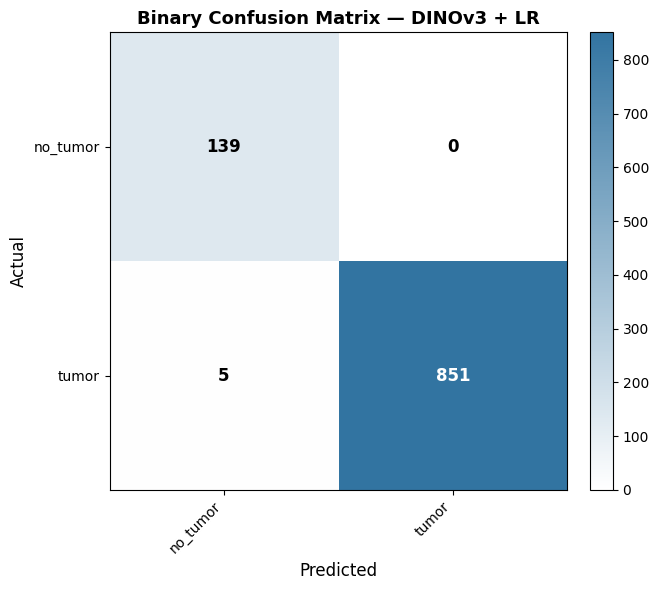

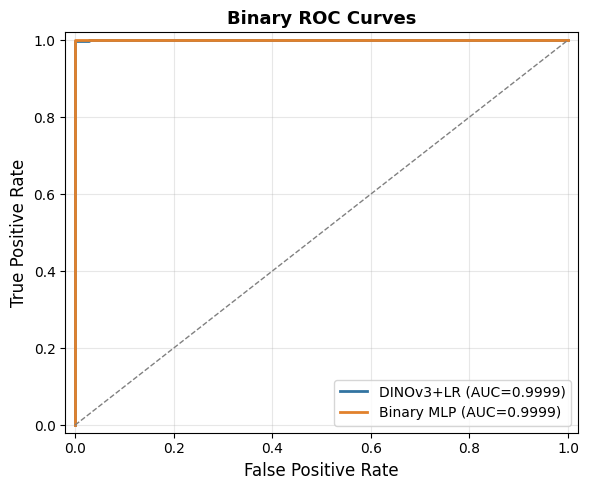

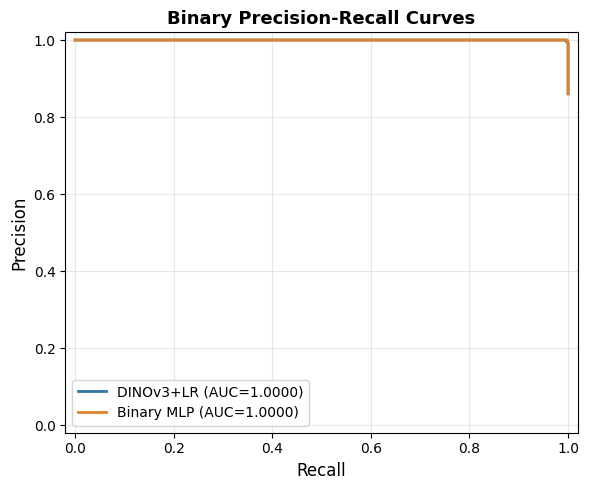


Binary bootstrap 95% CI (image-level, n=2000):
  A_DINOv3_LR_binary accuracy: 0.9950 [0.9899 - 0.9990]
  A_DINOv3_LR_binary balanced_accuracy: 0.9971 [0.9942 - 0.9994]
  A_DINOv3_LR_binary f1: 0.9971 [0.9942 - 0.9994]
  A_DINOv3_LR_binary sensitivity: 0.9942 [0.9885 - 0.9988]
  Binary_B_ResNet50_MLP accuracy: 0.9950 [0.9899 - 0.9990]
  Binary_B_ResNet50_MLP balanced_accuracy: 0.9850 [0.9692 - 0.9964]
  Binary_B_ResNet50_MLP f1: 0.9971 [0.9943 - 0.9994]
  Binary_B_ResNet50_MLP sensitivity: 0.9988 [0.9965 - 1.0000]
Saved to results_binary/binary_bootstrap_ci.csv


In [38]:
# --- Binary Plots -----------------------------------------------------------
# Confusion matrix
cm_bin = confusion_matrix(y_test_bin, bin_preds_lr)
plot_confusion_matrix(cm_bin, BINARY_NAMES,
    "Binary Confusion Matrix — DINOv3 + LR",
    str(OUT_DIRS["out_binary"] / "binary_confusion_lr"), normalize=False)

# ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test_bin, bin_probs_lr)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test_bin, bin_probs_mlp)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_lr, tpr_lr, color="#3274a1", lw=2,
        label=f"DINOv3+LR (AUC={bin_metrics_lr.get('roc_auc', 0):.4f})")
ax.plot(fpr_mlp, tpr_mlp, color="#e1812c", lw=2,
        label=f"Binary MLP (AUC={bin_metrics_mlp.get('roc_auc', 0):.4f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("Binary ROC Curves", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
for ext in ["png", "pdf"]:
    fig.savefig(OUT_DIRS["out_binary"] / f"binary_roc_curves.{ext}",
                dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# Precision-Recall curve
prec_lr, rec_lr, _ = precision_recall_curve(y_test_bin, bin_probs_lr)
prec_mlp, rec_mlp, _ = precision_recall_curve(y_test_bin, bin_probs_mlp)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rec_lr, prec_lr, color="#3274a1", lw=2,
        label=f"DINOv3+LR (AUC={bin_metrics_lr.get('pr_auc', 0):.4f})")
ax.plot(rec_mlp, prec_mlp, color="#e1812c", lw=2,
        label=f"Binary MLP (AUC={bin_metrics_mlp.get('pr_auc', 0):.4f})")
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Binary Precision-Recall Curves", fontsize=13, fontweight="bold")
ax.legend(loc="lower left", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
for ext in ["png", "pdf"]:
    fig.savefig(OUT_DIRS["out_binary"] / f"binary_pr_curves.{ext}",
                dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# --- Binary bootstrap CI ----------------------------------------------------
rng_boot_bin = np.random.RandomState(42)

def bootstrap_ci_bin(y_true, y_pred, metric_fn, n_boot=CONFIG["n_bootstrap"]):
    scores = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng_boot_bin.randint(0, n, n)
        try:
            scores.append(metric_fn(y_true[idx], y_pred[idx]))
        except Exception:
            continue
    scores = np.array(scores)
    return np.percentile(scores, 2.5), np.percentile(scores, 97.5)

print("\nBinary bootstrap 95% CI (image-level, n=2000):")
bin_boot_rows = []
for model_name, preds, probs in [
    ("A_DINOv3_LR_binary", bin_preds_lr, bin_probs_lr),
    (f"Binary_{best_model_name}_MLP", bin_preds_mlp, bin_probs_mlp),
]:
    for metric_name, fn in [
        ("accuracy", accuracy_score),
        ("balanced_accuracy", balanced_accuracy_score),
        ("f1", lambda yt, yp: f1_score(yt, yp, zero_division=0)),
        ("sensitivity", lambda yt, yp: recall_score(yt, yp, zero_division=0)),
    ]:
        pt = fn(y_test_bin, preds)
        lo, hi = bootstrap_ci_bin(y_test_bin, preds, fn)
        bin_boot_rows.append({
            "model": model_name, "metric": metric_name,
            "point_estimate": pt, "ci95_lower": lo, "ci95_upper": hi,
        })
        print(f"  {model_name} {metric_name}: {pt:.4f} [{lo:.4f} - {hi:.4f}]")

df_bin_boot = pd.DataFrame(bin_boot_rows)
df_bin_boot.to_csv(OUT_DIRS["out_binary"] / "binary_bootstrap_ci.csv", index=False)
print(f"Saved to {OUT_DIRS['out_binary'] / 'binary_bootstrap_ci.csv'}")

## Section 29 — Experiment Manifest

In [39]:
# Gather all output files
all_output_files = []
for out_dir in OUT_DIRS.values():
    for p in sorted(out_dir.rglob("*")):
        if p.is_file():
            all_output_files.append(str(p))

manifest = {
    "experiment_title": "BRISC DINOv3 Classification Experiments — Revised Paper",
    "dataset": {
        "name": "BRISC Brain Tumor MRI",
        "original_path": ORIGINAL_ROOT,
        "cleaned_path": CLEAN_ROOT,
        "original_train_count": len(df_orig_train),
        "original_test_count": len(df_orig_test),
        "clean_train_count": len(df_clean_train),
        "clean_test_count": len(df_clean_test),
        "removed_exact_duplicates": len(df_removed),
        "class_names": CLASS_NAMES,
    },
    "split": {
        "val_fraction": CONFIG["val_split"],
        "split_seed": 42,
        "split_level": "image_level",
        "patient_level_note": "Patient-level independence cannot be verified (no patient IDs)",
    },
    "seeds": CONFIG["seeds"],
    "model_checkpoint": CONFIG["model_id"],
    "models": {
        "A_DINOv3_LR_clean": {
            "type": "Frozen DINOv3 + Logistic Regression",
            "classifier": "sklearn LogisticRegression",
            "C": CONFIG["C"], "max_iter": CONFIG["max_iter"],
        },
        "B_ResNet50": {
            "type": "ImageNet-pretrained ResNet50 transfer learning",
            "epochs": CONFIG["epochs_resnet"],
            "lr": CONFIG["lr_resnet"],
        },
        "C_DINOv3_MLP": {
            "type": "Frozen DINOv3 + MLP (768->256->4)",
            "dropout": CONFIG["dropout"],
            "epochs": CONFIG["epochs_mlp"],
            "lr": CONFIG["lr_head"],
        },
        "D_DINOv3_Last1Block": {
            "type": "DINOv3 last transformer block + MLP",
            "trainable_blocks": 1,
            "lr_backbone": CONFIG["lr_backbone"],
            "lr_head": CONFIG["lr_head"],
            "epochs": CONFIG["epochs_finetune"],
        },
        "E_DINOv3_Last4Blocks": {
            "type": "DINOv3 last 4 transformer blocks + MLP",
            "trainable_blocks": 4,
            "lr_backbone": CONFIG["lr_backbone"],
            "lr_head": CONFIG["lr_head"],
            "epochs": CONFIG["epochs_finetune"],
        },
    },
    "training": {
        "optimizer": "Adam",
        "weight_decay": CONFIG["weight_decay"],
        "batch_size": CONFIG["batch_size"],
        "early_stopping_patience": CONFIG["patience"],
        "scheduler": "ReduceLROnPlateau(factor=0.5, patience=3)",
    },
    "augmentation_conditions": [
        "minimal (resize + normalize only)",
        "conservative_mri (rotation=10, translate=0.05, scale=0.95-1.05)",
        "aggressive_original (RandAugment + HFlip + VFlip + ColorJitter + RandomErasing)",
    ],
    "preprocessing": {
        "img_size": CONFIG["img_size"],
        "normalization": "ImageNet (mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])",
    },
    "selected_model": best_model_name,
    "software_versions": env_info,
    "output_files": all_output_files,
    "timestamp": datetime.now().isoformat(),
}

manifest_path = OUT_DIRS["out_comparison"] / "experiment_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)

print(f"Experiment manifest saved to {manifest_path}")
print(json.dumps(manifest, indent=2, default=str))

Experiment manifest saved to results_model_comparison/experiment_manifest.json
{
  "experiment_title": "BRISC DINOv3 Classification Experiments \u2014 Revised Paper",
  "dataset": {
    "name": "BRISC Brain Tumor MRI",
    "original_path": "/content/BRISC_original",
    "cleaned_path": "/content/BRISC_exact_cleaned",
    "original_train_count": 5000,
    "original_test_count": 1000,
    "clean_train_count": 4955,
    "clean_test_count": 995,
    "removed_exact_duplicates": 50,
    "class_names": [
      "glioma",
      "meningioma",
      "no",
      "pituitary"
    ]
  },
  "split": {
    "val_fraction": 0.15,
    "split_seed": 42,
    "split_level": "image_level",
    "patient_level_note": "Patient-level independence cannot be verified (no patient IDs)"
  },
  "seeds": [
    42,
    123,
    2026
  ],
  "model_checkpoint": "facebook/dinov3-vitb16-pretrain-lvd1689m",
  "models": {
    "A_DINOv3_LR_clean": {
      "type": "Frozen DINOv3 + Logistic Regression",
      "classifier": "skle

## Section 30 — Reviewer-Focused Summary

In [40]:
# Gather key results for summary
def safe_get(d, key, default="N/A"):
    v = d.get(key, default)
    return f"{v:.4f}" if isinstance(v, float) else str(v)

# Original baseline
orig_acc = safe_get(orig_test_metrics, "accuracy")
orig_f1 = safe_get(orig_test_metrics, "macro_f1")

# Clean baseline
clean_acc = safe_get(clean_test_metrics_lr, "accuracy")
clean_f1 = safe_get(clean_test_metrics_lr, "macro_f1")

# Selected model
sel_acc = safe_get(selected_metrics, "accuracy")
sel_f1 = safe_get(selected_metrics, "macro_f1")

# ResNet50
rn_acc = safe_get(resnet_metrics, "accuracy")
rn_f1 = safe_get(resnet_metrics, "macro_f1")

# Seed summary for selected model
sel_seed = df_seed_summary[
    (df_seed_summary["model"] == best_model_name) &
    (df_seed_summary["metric"] == "accuracy")
] if best_model_name in df_seed_summary["model"].values else pd.DataFrame()

if len(sel_seed) > 0:
    seed_mean = f"{sel_seed.iloc[0]['mean']:.4f}"
    seed_std = f"{sel_seed.iloc[0]['std']:.4f}"
else:
    # Fall back to LR
    lr_seed = df_seed_summary[
        (df_seed_summary["model"] == "A_DINOv3_LR_clean") &
        (df_seed_summary["metric"] == "accuracy")
    ]
    seed_mean = f"{lr_seed.iloc[0]['mean']:.4f}" if len(lr_seed) > 0 else "N/A"
    seed_std = f"{lr_seed.iloc[0]['std']:.4f}" if len(lr_seed) > 0 else "N/A"

# CV summary
cv_lr = df_cv_summary[
    (df_cv_summary["model"] == "A_DINOv3_LR_clean") &
    (df_cv_summary["metric"] == "accuracy")
]
cv_mean = f"{cv_lr.iloc[0]['mean']:.4f}" if len(cv_lr) > 0 else "N/A"
cv_std = f"{cv_lr.iloc[0]['std']:.4f}" if len(cv_lr) > 0 else "N/A"

# Augmentation best
if len(df_aug) > 0:
    best_aug_row = df_aug.sort_values("macro_f1", ascending=False).iloc[0]
    best_aug_cond = best_aug_row["condition"]
    best_aug_f1 = f"{best_aug_row['macro_f1']:.4f}"
else:
    best_aug_cond = "N/A"
    best_aug_f1 = "N/A"

# Calibration
if len(df_cal) > 0:
    cal_summary = "; ".join([f"{r['model']}: ECE={r['ECE']:.4f}" for _, r in df_cal.iterrows()])
else:
    cal_summary = "N/A"

# Binary
bin_acc_lr = safe_get(bin_metrics_lr, "accuracy")
bin_f1_lr = safe_get(bin_metrics_lr, "f1")

print()
print("=" * 100)
print("REVIEWER-FOCUSED EXPERIMENT SUMMARY")
print("=" * 100)
print()
print(f"1.  Original frozen DINOv3 + LR baseline (BRISC_original):")
print(f"    Accuracy: {orig_acc}  |  Macro F1: {orig_f1}")
print()
print(f"2.  Clean frozen DINOv3 + LR baseline (BRISC_exact_cleaned):")
print(f"    Accuracy: {clean_acc}  |  Macro F1: {clean_f1}")
print()
print(f"3.  Effect of exact duplicate removal:")
print(f"    {len(df_removed)} exact duplicate images removed ({n_cross} cross-split groups)")
print(f"    Training: {len(df_orig_train)} -> {len(df_clean_train)} images")
print(f"    Testing:  {len(df_orig_test)} -> {len(df_clean_test)} images")
print()
print(f"4.  Best model architecture: {best_model_name}")
print(f"    Test Accuracy: {sel_acc}  |  Test Macro F1: {sel_f1}")
print()
print(f"5.  Performance vs frozen DINOv3 LR baseline:")
d_acc = float(sel_acc) - float(clean_acc) if sel_acc != "N/A" and clean_acc != "N/A" else 0
d_f1 = float(sel_f1) - float(clean_f1) if sel_f1 != "N/A" and clean_f1 != "N/A" else 0
print(f"    Accuracy delta: {d_acc:+.4f}  |  Macro F1 delta: {d_f1:+.4f}")
print()
print(f"6.  Performance vs ResNet50:")
dr_acc = float(sel_acc) - float(rn_acc) if sel_acc != "N/A" and rn_acc != "N/A" else 0
dr_f1 = float(sel_f1) - float(rn_f1) if sel_f1 != "N/A" and rn_f1 != "N/A" else 0
print(f"    Accuracy delta: {dr_acc:+.4f}  |  Macro F1 delta: {dr_f1:+.4f}")
print()
print(f"7.  Three-seed mean ± SD:  Accuracy = {seed_mean} ± {seed_std}")
print()
print(f"8.  Five-fold CV mean ± SD: Accuracy = {cv_mean} ± {cv_std}")
print()
print(f"9.  Best augmentation condition: {best_aug_cond} (Macro F1 = {best_aug_f1})")
print()
print(f"10. Calibration: {cal_summary}")
print()
print(f"11. Independent binary experiment:")
print(f"    DINOv3 + LR binary — Accuracy: {bin_acc_lr}  |  F1: {bin_f1_lr}")
print()
print(f"12. Number of exact duplicates removed: {len(df_removed)}")
print()
print(f"13. IMPORTANT: Near-duplicate images (perceptually similar but not byte-identical)")
print(f"    were intentionally NOT removed. Only exact SHA-256 byte-identical files were cleaned.")
print()
print(f"14. IMPORTANT: Patient-level independence CANNOT be verified because reliable")
print(f"    patient identifiers are not available in the current dataset metadata.")
print(f"    All splitting was performed at the IMAGE level.")
print()
print(f"15. All intermediate CSVs, manifests, model checkpoints, and figures have been")
print(f"    preserved so that every number in the revised manuscript can be traced back")
print(f"    to this experiment notebook.")
print()
print("=" * 100)
print("EXPERIMENT COMPLETE")
print("=" * 100)


REVIEWER-FOCUSED EXPERIMENT SUMMARY

1.  Original frozen DINOv3 + LR baseline (BRISC_original):
    Accuracy: 0.9670  |  Macro F1: 0.9709

2.  Clean frozen DINOv3 + LR baseline (BRISC_exact_cleaned):
    Accuracy: 0.9638  |  Macro F1: 0.9668

3.  Effect of exact duplicate removal:
    50 exact duplicate images removed (7 cross-split groups)
    Training: 5000 -> 4955 images
    Testing:  1000 -> 995 images

4.  Best model architecture: B_ResNet50
    Test Accuracy: 0.9839  |  Test Macro F1: 0.9850

5.  Performance vs frozen DINOv3 LR baseline:
    Accuracy delta: +0.0201  |  Macro F1 delta: +0.0182

6.  Performance vs ResNet50:
    Accuracy delta: +0.0000  |  Macro F1 delta: +0.0000

7.  Three-seed mean ± SD:  Accuracy = 0.9876 ± 0.0035

8.  Five-fold CV mean ± SD: Accuracy = 0.9613 ± 0.0078

9.  Best augmentation condition: aggressive_original (Macro F1 = 0.9930)

10. Calibration: A_DINOv3_LR_clean: ECE=0.0074; B_ResNet50: ECE=0.0085

11. Independent binary experiment:
    DINOv3 + L